# Predicción temporal de reapertura de bugs con horizonte de 180 días

Este notebook evalúa el uso operativo del modelo en el momento de la primera resolución de un bug. La pregunta representada es:

> A partir de la información disponible cuando un bug se resuelve por primera vez, ¿puede estimarse el riesgo de que sea reabierto dentro de los 180 días siguientes?

El diseño evita tres formas de anticipación indebida:

1. Las variables de cada bug utilizan únicamente información disponible hasta su primera resolución.
2. El entrenamiento siempre contiene primeras resoluciones anteriores a las de validación y prueba.
3. Se aplica una brecha temporal de 180 días entre entrenamiento y evaluación, para que las etiquetas del conjunto de entrenamiento ya hubieran podido observarse en el momento simulado de predicción.

Se reserva el período global más reciente como test final y se utiliza validación cruzada temporal expansiva dentro del período de desarrollo. Se comparan regresión logística, Random Forest y LightGBM mediante PR-AUC, ROC-AUC y métricas de priorización.

**Política de faltantes:** no se imputa ningún valor. Regresión logística y Random Forest excluyen las variables incompletas. LightGBM conserva los valores `NaN` y los trata de forma nativa.

## 1. Importaciones y configuración

Por defecto se utiliza el dataset base, que excluye los IDs crudos de usuarios y conserva las variables históricas de experiencia y las relaciones entre creator, reporter, assignee y resolver.

El notebook valida explícitamente que los datasets exportados estén alineados, que no exista fuga de información y que los faltantes sean únicamente los esperados.


In [1]:
import gc
import hashlib
import json
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from pandas.api.types import CategoricalDtype
from scipy import sparse

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    import optuna
except ImportError as exc:
    raise ImportError(
        "Este notebook requiere Optuna. Instálelo con: pip install optuna"
    ) from exc

try:
    from lightgbm import LGBMClassifier, early_stopping, log_evaluation
except ImportError as exc:
    raise ImportError(
        "Este notebook requiere LightGBM. Instálelo con: pip install lightgbm"
    ) from exc


RANDOM_STATE = 42
SOURCE_TARGET_COL = "Reopened_Target"
TARGET_COL = "Reopened_Within_180_Days"
HORIZON_DAYS = 180
TEMPORAL_GAP_DAYS = HORIZON_DAYS
N_JOBS = max(1, min(8, os.cpu_count() or 1))

# Variante principal del trabajo.
MODELING_VARIANT = "base"

# Cambiar esta versión cuando se modifiquen las fórmulas de ingeniería
# de atributos, la política de imputación o el preprocesamiento.
# Forma parte del fingerprint para impedir reutilizar estudios Optuna
# y candidatos calculados sobre una representación anterior de los datos.
EXPERIMENT_VERSION = "advanced_logical_imputation_v2"

# Agrupación de categorías poco frecuentes para los modelos con one-hot.
# LightGBM no usa one-hot: trabaja con categorías nativas.
OHE_MIN_FREQUENCY = 5 if MODELING_VARIANT == "base" else 20

# Diseño temporal.
TEST_FRACTION_APPROX = 0.20
N_TEMPORAL_CV_SPLITS = 3
CV_VALIDATION_FRACTION = 0.15
MIN_PROJECT_HISTORY_BEFORE_TEST = 30

# Ponderación cronológica común a los tres modelos.
# El primer peso corresponde al fold más antiguo y el último
# al fold más reciente.
TEMPORAL_FOLD_WEIGHTS = np.asarray(
    [0.20, 0.30, 0.50],
    dtype=float,
)

if len(TEMPORAL_FOLD_WEIGHTS) != N_TEMPORAL_CV_SPLITS:
    raise ValueError(
        "La cantidad de pesos temporales debe coincidir con "
        "N_TEMPORAL_CV_SPLITS."
    )

if np.any(TEMPORAL_FOLD_WEIGHTS < 0):
    raise ValueError(
        "Los pesos temporales no pueden ser negativos."
    )

if TEMPORAL_FOLD_WEIGHTS.sum() <= 0:
    raise ValueError(
        "La suma de los pesos temporales debe ser mayor que cero."
    )

TEMPORAL_FOLD_WEIGHTS = (
    TEMPORAL_FOLD_WEIGHTS
    / TEMPORAL_FOLD_WEIGHTS.sum()
)


def weighted_temporal_average(values):
    """Promedio temporal usando los mismos pesos para todos los modelos."""
    values_array = np.asarray(values, dtype=float)

    if len(values_array) != len(TEMPORAL_FOLD_WEIGHTS):
        raise ValueError(
            "La cantidad de resultados de folds no coincide con "
            "la cantidad de pesos temporales. "
            f"Resultados: {len(values_array)}. "
            f"Pesos: {len(TEMPORAL_FOLD_WEIGHTS)}."
        )

    finite_mask = np.isfinite(values_array)
    if not finite_mask.any():
        return np.nan

    usable_weights = TEMPORAL_FOLD_WEIGHTS[finite_mask]
    usable_weights = usable_weights / usable_weights.sum()

    return float(
        np.average(
            values_array[finite_mask],
            weights=usable_weights,
        )
    )

# Cada prueba se evalúa en los mismos folds temporales expansivos.
RF_N_TRIALS = 20

# Optimización LightGBM en dos etapas.
LGBM_STRUCTURE_N_TRIALS = 50
LGBM_REGULARIZATION_N_TRIALS = 30
LGBM_MAX_BOOSTING_ROUNDS = 5000
LGBM_EARLY_STOPPING_ROUNDS = 150
LGBM_REEVALUATION_TOP_N = 5

# Semillero pequeño para reducir la variabilidad.
LGBM_ENSEMBLE_SEEDS = [101, 307, 509, 701, 907]
LGBM_STABILITY_PENALTY = 0.50

# Selección operativa por porcentaje de bugs revisados.
TOP_K_FRACTIONS = (0.05, 0.10, 0.15, 0.20)

# Si se cambia el diseño experimental, el fingerprint crea estudios
# nuevos. Activar esta opción solo para borrar la base SQLite actual.
RESET_OPTUNA_STUDIES = False

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 120)

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)

/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Localización, carga y alineación de los datasets

El dataset completo aporta identificadores y fechas de auditoría. El dataset de modelado define exactamente qué columnas están autorizadas como predictores.

Antes de modelar se comprueba, columna por columna, que ambos archivos tengan las mismas observaciones y el mismo orden.


In [2]:
MODEL_DATASET_FILES = {
    "base": "bug_reopen_modeling_dataset.parquet",
    "with_users": "bug_reopen_modeling_dataset_with_users.parquet",
}

if MODELING_VARIANT not in MODEL_DATASET_FILES:
    raise ValueError(
        f"MODELING_VARIANT debe ser una de {list(MODEL_DATASET_FILES)}"
    )


candidate_output_dirs = [
    Path("/app/output"),
    Path.cwd() / "output",
    Path("/mnt/data"),
]

required_model_filename = MODEL_DATASET_FILES[MODELING_VARIANT]

DATA_DIR = next(
    (
        directory
        for directory in candidate_output_dirs
        if (
            (directory / "bug_reopen_dataset_full.parquet").exists()
            and (directory / required_model_filename).exists()
        )
    ),
    None,
)

if DATA_DIR is None:
    searched = "\n".join(str(path) for path in candidate_output_dirs)
    raise FileNotFoundError(
        "No se encontraron los datasets requeridos. Se buscaron en:\n"
        f"{searched}"
    )

RESULTS_DIR = DATA_DIR / "modeling_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

full_dataset_path = DATA_DIR / "bug_reopen_dataset_full.parquet"
modeling_dataset_path = DATA_DIR / required_model_filename

full_dataset = pd.read_parquet(full_dataset_path)
modeling_dataset = pd.read_parquet(modeling_dataset_path)

print("Directorio de datos:", DATA_DIR)
print("Dataset completo:", full_dataset.shape)
print("Dataset de modelado:", modeling_dataset.shape)
print("Variante:", MODELING_VARIANT)


Directorio de datos: /app/output
Dataset completo: (67806, 198)
Dataset de modelado: (67806, 175)
Variante: base


In [3]:
required_full_columns = [
    "Issue_ID",
    "Project_ID",
    "First_Resolution_Date",
    "First_Resolution_Change_ID",
    "First_Reopen_Date",
    "Project_Observation_End_Date",
    SOURCE_TARGET_COL,
]

missing_required_columns = [
    col
    for col in required_full_columns
    if col not in full_dataset.columns
]

if missing_required_columns:
    raise ValueError(
        "Faltan columnas necesarias en el dataset completo: "
        f"{missing_required_columns}"
    )

if SOURCE_TARGET_COL not in modeling_dataset.columns:
    raise ValueError(
        "El dataset de modelado no contiene el target original "
        f"{SOURCE_TARGET_COL}"
    )

if len(full_dataset) != len(modeling_dataset):
    raise ValueError(
        "El dataset completo y el dataset de modelado tienen "
        "distinta cantidad de observaciones."
    )

missing_model_columns_in_full = sorted(
    set(modeling_dataset.columns) - set(full_dataset.columns)
)

if missing_model_columns_in_full:
    raise ValueError(
        "El dataset completo no contiene columnas presentes en el "
        f"dataset de modelado: {missing_model_columns_in_full}"
    )


def series_values_equal(left, right):
    """Compara valores ignorando diferencias inocuas de dtype."""
    left = left.reset_index(drop=True)
    right = right.reset_index(drop=True)

    if (
        pd.api.types.is_numeric_dtype(left)
        and pd.api.types.is_numeric_dtype(right)
    ):
        left_values = pd.to_numeric(left, errors="coerce").to_numpy(
            dtype="float64"
        )
        right_values = pd.to_numeric(right, errors="coerce").to_numpy(
            dtype="float64"
        )
        return np.array_equal(
            left_values,
            right_values,
            equal_nan=True,
        )

    left_values = left.astype("string").fillna("<NA>")
    right_values = right.astype("string").fillna("<NA>")
    return left_values.equals(right_values)


misaligned_columns = [
    col
    for col in modeling_dataset.columns
    if not series_values_equal(
        full_dataset[col],
        modeling_dataset[col],
    )
]

if misaligned_columns:
    raise ValueError(
        "Los datasets no están alineados por fila. Difieren estas columnas: "
        f"{misaligned_columns[:20]}"
    )

# Se construye el target de horizonte fijo sobre el dataset completo.
df_all = full_dataset.copy()

df_all["First_Resolution_Date"] = pd.to_datetime(
    df_all["First_Resolution_Date"],
    errors="raise",
)
df_all["First_Reopen_Date"] = pd.to_datetime(
    df_all["First_Reopen_Date"],
    errors="coerce",
)
df_all["Project_Observation_End_Date"] = pd.to_datetime(
    df_all["Project_Observation_End_Date"],
    errors="raise",
)

if df_all["Project_Observation_End_Date"].isna().any():
    raise ValueError(
        "Hay bugs sin fecha final de observación del proyecto."
    )

invalid_observation_windows = (
    df_all["Project_Observation_End_Date"]
    < df_all["First_Resolution_Date"]
)

if invalid_observation_windows.any():
    raise ValueError(
        "Hay bugs cuya primera resolución es posterior a la "
        "fecha final observable del proyecto. Cantidad: "
        f"{int(invalid_observation_windows.sum())}"
    )

source_target_values = set(
    df_all[SOURCE_TARGET_COL].dropna().astype(int).unique()
)
if not source_target_values.issubset({0, 1}):
    raise ValueError(
        "El target original contiene valores distintos de 0 y 1: "
        f"{sorted(source_target_values)}"
    )

positive_without_reopen_date = (
    df_all[SOURCE_TARGET_COL].eq(1)
    & df_all["First_Reopen_Date"].isna()
)
if positive_without_reopen_date.any():
    raise ValueError(
        "Hay positivos del target original sin First_Reopen_Date. "
        f"Cantidad: {int(positive_without_reopen_date.sum())}"
    )

df_all["days_resolution_to_reopen"] = (
    df_all["First_Reopen_Date"]
    - df_all["First_Resolution_Date"]
).dt.total_seconds() / 86400

df_all["followup_days"] = (
    df_all["Project_Observation_End_Date"]
    - df_all["First_Resolution_Date"]
).dt.total_seconds() / 86400

negative_reopen_times = (
    df_all.loc[
        df_all[SOURCE_TARGET_COL].eq(1),
        "days_resolution_to_reopen",
    ] < 0
).sum()
if negative_reopen_times:
    raise ValueError(
        "Hay reaperturas anteriores a la primera resolución. "
        f"Cantidad: {int(negative_reopen_times)}"
    )

# Para una cohorte comparable se exige una ventana observable completa
# de 180 días para todas las observaciones, incluso para los positivos.
eligible_horizon_mask = df_all["followup_days"].ge(HORIZON_DAYS)

df_all[TARGET_COL] = (
    df_all["days_resolution_to_reopen"]
    .between(0, HORIZON_DAYS, inclusive="both")
    .astype("int8")
)

horizon_exclusion_summary = pd.DataFrame({
    "concepto": [
        "observaciones_originales",
        "excluidas_sin_180_dias_completos",
        "observaciones_elegibles",
        "positivos_originales",
        "positivos_dentro_de_180_dias_elegibles",
    ],
    "n": [
        len(df_all),
        int((~eligible_horizon_mask).sum()),
        int(eligible_horizon_mask.sum()),
        int(df_all[SOURCE_TARGET_COL].sum()),
        int(df_all.loc[eligible_horizon_mask, TARGET_COL].sum()),
    ],
})

# A partir de aquí solo se modelan observaciones con seguimiento completo.
df = df_all.loc[eligible_horizon_mask].copy()

# Project_ID es una categoría, no una magnitud.
df["Project_ID"] = df["Project_ID"].astype("string")

USER_ID_COLUMNS = [
    "Creator_ID_At_First_Resolution",
    "Reporter_ID_At_First_Resolution",
    "Assignee_ID_At_First_Resolution",
    "Resolver_ID_At_First_Resolution",
]

if MODELING_VARIANT == "with_users":
    for col in USER_ID_COLUMNS:
        if col not in df.columns:
            raise ValueError(
                f"Falta la columna de usuario requerida: {col}"
            )
        df[col] = df[col].astype("string")

    upstream_missing_tokens = {
        col: int(df[col].eq("__MISSING__").sum())
        for col in USER_ID_COLUMNS
        if df[col].eq("__MISSING__").any()
    }

    if upstream_missing_tokens:
        raise ValueError(
            "El dataset con usuarios contiene el token '__MISSING__' "
            "creado en el notebook de construcción. Eso equivale a una "
            "codificación previa del faltante y viola la política de este "
            f"notebook. Columnas: {upstream_missing_tokens}"
        )

# El esquema de predictores procede del parquet aprobado. El target original
# se excluye explícitamente y el target de 180 días se construye aquí.
candidate_feature_cols = [
    col
    for col in modeling_dataset.columns
    if col != SOURCE_TARGET_COL
]

forbidden_leakage_columns = {
    SOURCE_TARGET_COL,
    TARGET_COL,
    "First_Reopen_Change_ID",
    "First_Reopen_Date",
    "First_Reopen_Status",
    "First_Reopen_Group",
    "Priority",
    "Assignee_ID",
    "Creator_ID",
    "Reporter_ID",
    "Story_Point",
    "Title",
    "Description",
    "Description_Text",
    "Description_Code",
    "Pull_Request_URL",
    "n_issue_links_at_first_resolution",
    "has_issue_links_at_first_resolution",
    "Project_Observation_End_Date",
    "days_resolution_to_reopen",
    "followup_days",
}

leaked_columns = sorted(
    forbidden_leakage_columns.intersection(candidate_feature_cols)
)

if leaked_columns:
    raise ValueError(
        "El dataset de modelado contiene columnas prohibidas: "
        f"{leaked_columns}"
    )

manual_excluded_features = [
    "resolution_time_hours",
]

candidate_feature_cols = [
    col
    for col in candidate_feature_cols
    if col not in manual_excluded_features
]

print("Alineación de datasets: correcta")
print("Horizonte del target:", HORIZON_DAYS, "días")
print("Observaciones elegibles:", len(df))
print("Predictores aprobados:", len(candidate_feature_cols))
display(horizon_exclusion_summary)

Alineación de datasets: correcta
Horizonte del target: 180 días
Observaciones elegibles: 66865
Predictores aprobados: 173


,concepto,n
0,observaciones_originales,67806
1,excluidas_sin_180_dias_completos,941
2,observaciones_elegibles,66865
3,positivos_originales,7635
4,positivos_dentro_de_180_dias_elegibles,7094


## 3. Auditoría de granularidad, variable objetivo y fechas


In [4]:
duplicate_issues = df.duplicated(
    ["Issue_ID", "Project_ID"]
).sum()

if duplicate_issues:
    raise ValueError(
        f"El dataset contiene {duplicate_issues} bugs duplicados."
    )

if df[TARGET_COL].isna().any():
    raise ValueError("La variable objetivo contiene valores faltantes.")

target_values = set(
    pd.to_numeric(df[TARGET_COL], errors="raise").unique()
)

if not target_values.issubset({0, 1}):
    raise ValueError(
        f"La variable objetivo no es binaria: {sorted(target_values)}"
    )

df[TARGET_COL] = df[TARGET_COL].astype("int8")

if df["First_Resolution_Date"].isna().any():
    raise ValueError("Hay bugs sin fecha de primera resolución.")

if df["First_Resolution_Change_ID"].isna().any():
    raise ValueError("Hay bugs sin Change_ID de primera resolución.")

target_summary = pd.DataFrame({
    "métrica": [
        "bugs con primera resolución",
        "bugs reabiertos",
        "bugs no reabiertos",
        "tasa de reapertura (%)",
        "bugs duplicados",
    ],
    "valor": [
        len(df),
        int(df[TARGET_COL].sum()),
        int((df[TARGET_COL] == 0).sum()),
        round(100 * df[TARGET_COL].mean(), 2),
        int(duplicate_issues),
    ],
})

target_summary


,métrica,valor
0,bugs con primera resolución,66865.00
1,bugs reabiertos,7094.00
2,bugs no reabiertos,59771.00
3,tasa de reapertura (%),10.61
4,bugs duplicados,0.00


,Reopened_Within_180_Days,n,porcentaje
0,0,59771,89.39
1,1,7094,10.61


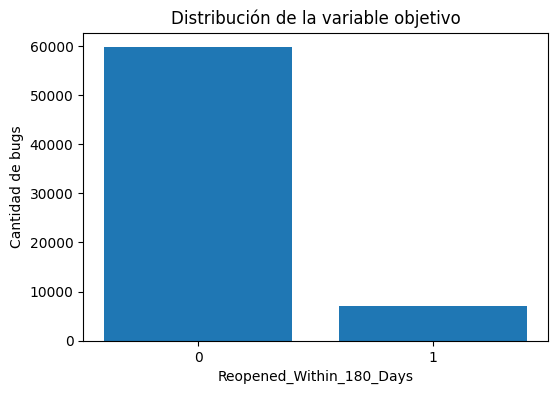

In [5]:
target_counts = (
    df[TARGET_COL]
    .value_counts()
    .rename_axis(TARGET_COL)
    .reset_index(name="n")
)

target_counts["porcentaje"] = (
    100 * target_counts["n"] / len(df)
).round(2)

display(target_counts)

plt.figure(figsize=(6, 4))
plt.bar(
    target_counts[TARGET_COL].astype(str),
    target_counts["n"],
)
plt.xlabel(TARGET_COL)
plt.ylabel("Cantidad de bugs")
plt.title("Distribución de la variable objetivo")
plt.show()


## 4. Análisis exploratorio


,Project_ID,bugs,bugs_reabiertos,tasa_reapertura_pct
1,13,3162,834,26.38
5,7,596,121,20.30
0,12,14444,2737,18.95
4,42,5072,804,15.85
6,8,5054,638,12.62
7,9,367,42,11.44
3,36,5345,555,10.38
2,34,32825,1363,4.15


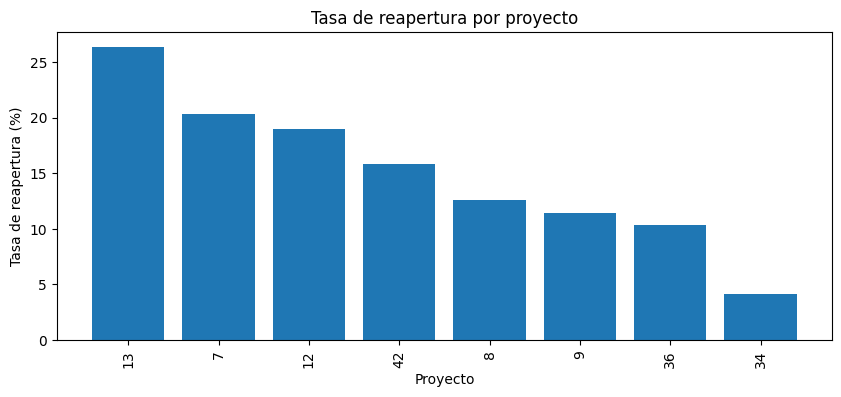

In [6]:
target_by_project = (
    df.groupby("Project_ID", dropna=False)
    .agg(
        bugs=("Issue_ID", "count"),
        bugs_reabiertos=(TARGET_COL, "sum"),
    )
    .reset_index()
)

target_by_project["tasa_reapertura_pct"] = (
    100
    * target_by_project["bugs_reabiertos"]
    / target_by_project["bugs"]
).round(2)

display(
    target_by_project.sort_values(
        "tasa_reapertura_pct",
        ascending=False,
    )
)

target_by_project_plot = target_by_project.sort_values(
    "tasa_reapertura_pct",
    ascending=False,
)

plt.figure(figsize=(10, 4))
plt.bar(
    target_by_project_plot["Project_ID"].astype(str),
    target_by_project_plot["tasa_reapertura_pct"],
)
plt.xlabel("Proyecto")
plt.ylabel("Tasa de reapertura (%)")
plt.title("Tasa de reapertura por proyecto")
plt.xticks(rotation=90)
plt.show()


In [7]:
eda_numeric_cols = [
    "resolution_time_days",
    "n_changes_until_resolution",
    "n_change_authors_until_resolution",
    "n_status_events_until_resolution",
    "n_distinct_to_statuses_until_resolution",
    "n_comments_until_resolution",
    "n_comment_authors_until_resolution",
    "comment_text_total_length_until_resolution",
    "n_priority_changes_until_resolution",
    "n_components_at_first_resolution",
    "n_affected_versions_at_first_resolution",
    "n_fix_versions_at_first_resolution",
    "assignee_previous_resolved_bugs_in_project",
    "resolver_previous_resolutions_in_project",
    "reporter_previous_resolved_bugs_in_project",
    "creator_previous_resolved_bugs_in_project",
]

eda_numeric_cols = [
    col for col in eda_numeric_cols if col in df.columns
]

numeric_by_target = (
    df.groupby(TARGET_COL)[eda_numeric_cols]
    .mean()
    .T
    .reset_index()
)

numeric_by_target.columns = [
    "variable",
    "media_no_reabierto",
    "media_reabierto",
]

numeric_by_target["diferencia_absoluta"] = (
    numeric_by_target["media_reabierto"]
    - numeric_by_target["media_no_reabierto"]
)

numeric_by_target["diferencia_pct"] = (
    100
    * numeric_by_target["diferencia_absoluta"]
    / numeric_by_target["media_no_reabierto"].replace(0, np.nan)
).round(2)

numeric_by_target.sort_values(
    "diferencia_pct",
    ascending=False,
)


,variable,media_no_reabierto,media_reabierto,diferencia_absoluta,diferencia_pct
8,n_priority_changes_until_resolution,0.362935,0.480265,0.117330,32.33
11,n_fix_versions_at_first_resolution,0.779458,1.011136,0.231678,29.72
9,n_components_at_first_resolution,1.083050,1.024246,-0.058804,-5.43
2,n_change_authors_until_resolution,3.165950,2.975895,-0.190055,-6.00
1,n_changes_until_resolution,14.333071,12.708204,-1.624867,-11.34
10,n_affected_versions_at_first_resolution,1.171137,0.954610,-0.216527,-18.49
6,n_comment_authors_until_resolution,2.377892,1.907668,-0.470224,-19.77
4,n_distinct_to_statuses_until_resolution,2.466715,1.856217,-0.610498,-24.75
14,reporter_previous_resolved_bugs_in_project,80.347175,59.067381,-21.279794,-26.48
5,n_comments_until_resolution,4.399809,3.234564,-1.165245,-26.48


In [8]:
binary_cols = [
    "had_validation_until_resolution",
    "had_active_return_from_validation_until_resolution",
    "had_reopen_like_transition_until_resolution",
    "has_comment_text_until_resolution",
    "has_comment_code_until_resolution",
    "had_priority_change_until_resolution",
    "has_component_at_first_resolution",
    "has_affected_version_at_first_resolution",
    "has_fix_version_at_first_resolution",
    "has_creator",
    "has_reporter",
    "has_assignee",
    "has_resolver",
    "creator_eq_reporter",
    "creator_eq_assignee",
    "reporter_eq_assignee",
    "resolver_eq_assignee",
    "resolver_eq_reporter",
    "resolver_eq_creator",
    "creator_is_new_in_project",
    "reporter_is_new_in_project",
    "assignee_is_new_in_project",
    "resolver_is_new_in_project",
]

binary_cols = [
    col for col in binary_cols if col in df.columns
]

binary_by_target = (
    df.groupby(TARGET_COL)[binary_cols]
    .mean()
    .T
    .reset_index()
)

binary_by_target.columns = [
    "variable",
    "proporcion_no_reabierto",
    "proporcion_reabierto",
]

binary_by_target["diferencia_pp"] = (
    100
    * (
        binary_by_target["proporcion_reabierto"]
        - binary_by_target["proporcion_no_reabierto"]
    )
).round(2)

binary_by_target["proporcion_no_reabierto"] = (
    100 * binary_by_target["proporcion_no_reabierto"]
).round(2)

binary_by_target["proporcion_reabierto"] = (
    100 * binary_by_target["proporcion_reabierto"]
).round(2)

binary_by_target.sort_values(
    "diferencia_pp",
    ascending=False,
)


,variable,proporcion_no_reabierto,proporcion_reabierto,diferencia_pp
8,has_fix_version_at_first_resolution,54.85,66.38,11.53
5,had_priority_change_until_resolution,30.62,40.37,9.76
16,resolver_eq_assignee,38.41,44.84,6.43
11,has_assignee,81.65,85.24,3.59
4,has_comment_code_until_resolution,10.09,11.69,1.59
22,resolver_is_new_in_project,1.11,2.35,1.24
21,assignee_is_new_in_project,1.16,1.62,0.46
9,has_creator,99.71,99.94,0.23
10,has_reporter,99.70,99.90,0.20
18,resolver_eq_creator,13.19,13.32,0.13


In [9]:
priority_target = (
    df.groupby(
        "Priority_At_First_Resolution",
        dropna=False,
    )
    .agg(
        bugs=("Issue_ID", "count"),
        bugs_reabiertos=(TARGET_COL, "sum"),
    )
    .reset_index()
)

priority_target["tasa_reapertura_pct"] = (
    100
    * priority_target["bugs_reabiertos"]
    / priority_target["bugs"]
).round(2)

priority_target.sort_values(
    "tasa_reapertura_pct",
    ascending=False,
)


,Priority_At_First_Resolution,bugs,bugs_reabiertos,tasa_reapertura_pct
0,6,2675,755,28.22
3,High,6863,1530,22.29
10,<NA>,1685,338,20.06
2,Critical,6098,892,14.63
6,Medium,7611,1090,14.32
4,Low,4510,478,10.60
1,Blocker,2532,237,9.36
9,Trivial,2888,231,8.00
5,Major,9775,689,7.05
8,To be reviewed,553,32,5.79


In [10]:
resolution_status_target = (
    df.groupby(
        "First_Resolution_Status",
        dropna=False,
    )
    .agg(
        bugs=("Issue_ID", "count"),
        bugs_reabiertos=(TARGET_COL, "sum"),
    )
    .reset_index()
)

resolution_status_target["tasa_reapertura_pct"] = (
    100
    * resolution_status_target["bugs_reabiertos"]
    / resolution_status_target["bugs"]
).round(2)

resolution_status_target.sort_values(
    ["bugs", "tasa_reapertura_pct"],
    ascending=[False, False],
).head(30)


,First_Resolution_Status,bugs,bugs_reabiertos,tasa_reapertura_pct
2,Resolved,34023,5522,16.23
0,Closed,22819,1357,5.95
3,Tested,10019,215,2.15
1,Done,4,0,0.00


In [11]:
missing_summary = (
    df[candidate_feature_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

missing_summary.columns = [
    "variable",
    "missing_count",
]

missing_summary["missing_pct"] = (
    100 * missing_summary["missing_count"] / len(df)
).round(2)

BASE_EXPECTED_MISSING_FEATURES = {
    "Story_Point_At_First_Resolution",
    "Priority_At_First_Resolution",
    "hours_first_comment_to_resolution",
    "hours_last_comment_to_resolution",
}

# Estas variables históricas pueden tener NaN legítimos cuando todavía
# no existe suficiente historia previa observable. No se imputan.
TEMPORAL_MISSING_PREFIXES = (
    "project_median_",
    "project_reopen_rate_",
    "project_previous_reopen_rate_",
    "creator_previous_reopen_rate_",
    "reporter_previous_reopen_rate_",
    "assignee_previous_reopen_rate_",
    "resolver_previous_reopen_rate_",
    "resolution_time_vs_project_median_",
    "comments_vs_project_median_",
    "status_events_vs_project_median_",
    "changes_vs_project_median_",
    "project_resolution_activity_ratio_",
    "project_reopen_event_activity_ratio_",
    "creator_recent_reopen_rate_",
    "reporter_recent_reopen_rate_",
    "assignee_recent_reopen_rate_",
    "resolver_recent_reopen_rate_",
    "creator_recent_vs_lifetime_reopen_rate_",
    "reporter_recent_vs_lifetime_reopen_rate_",
    "assignee_recent_vs_lifetime_reopen_rate_",
    "resolver_recent_vs_lifetime_reopen_rate_",
)

observed_missing_features = set(
    missing_summary.loc[
        missing_summary["missing_count"] > 0,
        "variable",
    ]
)

allowed_temporal_missing_features = {
    col
    for col in candidate_feature_cols
    if col.startswith(TEMPORAL_MISSING_PREFIXES)
}

ALLOWED_MISSING_FEATURES = (
    BASE_EXPECTED_MISSING_FEATURES
    | allowed_temporal_missing_features
)

unexpected_missing_features = sorted(
    observed_missing_features - ALLOWED_MISSING_FEATURES
)

if unexpected_missing_features:
    raise ValueError(
        "Aparecieron faltantes en variables no autorizadas: "
        f"{unexpected_missing_features}"
    )

# No se exige que todas las variables base tengan faltantes: el patrón
# puede cambiar entre variantes del dataset sin ser un error.

# No se permiten infinitos en predictores numéricos.
numeric_candidate_cols = [
    col
    for col in candidate_feature_cols
    if pd.api.types.is_numeric_dtype(df[col])
]

infinite_counts = {
    col: int(np.isinf(pd.to_numeric(df[col], errors="coerce")).sum())
    for col in numeric_candidate_cols
    if np.isinf(pd.to_numeric(df[col], errors="coerce")).any()
}

if infinite_counts:
    raise ValueError(
        f"Hay valores infinitos en predictores: {infinite_counts}"
    )

# Auditoría semántica de las duraciones respecto de comentarios.
comment_required = {
    "n_comments_until_resolution",
    "hours_first_comment_to_resolution",
    "hours_last_comment_to_resolution",
}

if comment_required.issubset(df.columns):
    n_comments = pd.to_numeric(
        df["n_comments_until_resolution"],
        errors="raise",
    )

    first_hours = pd.to_numeric(
        df["hours_first_comment_to_resolution"],
        errors="coerce",
    )

    last_hours = pd.to_numeric(
        df["hours_last_comment_to_resolution"],
        errors="coerce",
    )

    first_missing = first_hours.isna()
    last_missing = last_hours.isna()
    no_comments = n_comments.eq(0)

    if not first_missing.equals(last_missing):
        raise ValueError(
            "Los faltantes de first/last comment no coinciden."
        )

    inconsistent_missing = first_missing.ne(no_comments)

    if inconsistent_missing.any():
        raise ValueError(
            "Los faltantes de las duraciones de comentarios no coinciden "
            "con n_comments_until_resolution == 0. Filas inconsistentes: "
            f"{int(inconsistent_missing.sum())}"
        )

    valid_comment_times = ~first_missing

    if (first_hours[valid_comment_times] < 0).any():
        raise ValueError(
            "Hay horas negativas entre el primer comentario y la resolución."
        )

    if (last_hours[valid_comment_times] < 0).any():
        raise ValueError(
            "Hay horas negativas entre el último comentario y la resolución."
        )

    if (
        first_hours[valid_comment_times]
        < last_hours[valid_comment_times]
    ).any():
        raise ValueError(
            "La distancia desde el primer comentario a la resolución "
            "debe ser mayor o igual que la del último comentario."
        )

# Control de duraciones de resolución.
if "resolution_time_days" in df.columns:
    if (
        pd.to_numeric(
            df["resolution_time_days"],
            errors="raise",
        ) < 0
    ).any():
        raise ValueError(
            "Hay tiempos de resolución negativos."
        )

dataset_audit = pd.DataFrame({
    "control": [
        "filas",
        "predictores aprobados",
        "faltantes inesperados",
        "valores infinitos",
        "bugs duplicados",
        "target faltante",
    ],
    "resultado": [
        len(df),
        len(candidate_feature_cols),
        len(unexpected_missing_features),
        len(infinite_counts),
        int(duplicate_issues),
        int(df[TARGET_COL].isna().sum()),
    ],
})

display(dataset_audit)
display(
    missing_summary.loc[
        missing_summary["missing_count"] > 0
    ]
)


,control,resultado
0,filas,66865
1,predictores aprobados,173
2,faltantes inesperados,0
3,valores infinitos,0
4,bugs duplicados,0
5,target faltante,0


,variable,missing_count,missing_pct
0,Story_Point_At_First_Resolution,59639,89.19
1,creator_recent_reopen_rate_180d_in_project,32367,48.41
2,reporter_recent_reopen_rate_180d_in_project,32346,48.38
3,assignee_recent_reopen_rate_180d_in_project,26694,39.92
4,creator_previous_reopen_rate_180d_in_project,25614,38.31
5,reporter_previous_reopen_rate_180d_in_project,25591,38.27
6,assignee_previous_reopen_rate_180d_in_project,25128,37.58
7,assignee_previous_reopen_rate_180d_smoothed_in...,19804,29.62
8,resolver_recent_reopen_rate_180d_in_project,17374,25.98
9,resolver_previous_reopen_rate_180d_in_project,16025,23.97


## 5. Partición temporal global y validación expansiva

La evaluación principal simula el uso operativo del modelo:

- las observaciones se ordenan globalmente por `First_Resolution_Date`, `First_Resolution_Change_ID` e `Issue_ID`;
- el período más reciente se reserva como test final;
- entre desarrollo y test se deja una brecha de 180 días, equivalente al horizonte del target;
- dentro de desarrollo se construyen tres folds temporales expansivos;
- en cada fold también se elimina del entrenamiento la franja de 180 días anterior al inicio de la validación;
- el test no participa en la selección de variables, hiperparámetros ni umbrales.

La brecha evita utilizar como entrenamiento bugs cuya etiqueta a 180 días todavía no habría estado disponible en el momento simulado de evaluación.

In [12]:
sort_columns = [
    "First_Resolution_Date",
    "First_Resolution_Change_ID",
    "Issue_ID",
]

df_model = (
    df.sort_values(sort_columns)
    .reset_index(drop=True)
    .copy()
)

n_total = len(df_model)
initial_test_position = max(
    1,
    int(np.floor(n_total * (1.0 - TEST_FRACTION_APPROX))),
)
initial_test_position = min(initial_test_position, n_total - 1)
initial_test_date = df_model.loc[
    initial_test_position,
    "First_Resolution_Date",
]

# Se busca una fecha de inicio del test cercana al 20 % final, pero que
# garantice historia previa suficiente para cada proyecto presente en test.
candidate_test_dates = (
    df_model.loc[
        df_model["First_Resolution_Date"].ge(initial_test_date),
        "First_Resolution_Date",
    ]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

selected_test_start_date = None
selected_development_end_date = None

for candidate_test_start in candidate_test_dates:
    candidate_development_end = (
        candidate_test_start
        - pd.Timedelta(days=TEMPORAL_GAP_DAYS)
    )

    candidate_development = df_model.loc[
        df_model["First_Resolution_Date"].le(
            candidate_development_end
        )
    ]
    candidate_test = df_model.loc[
        df_model["First_Resolution_Date"].ge(
            candidate_test_start
        )
    ]

    if candidate_development.empty or candidate_test.empty:
        continue

    development_counts = (
        candidate_development["Project_ID"].value_counts()
    )
    test_projects = set(candidate_test["Project_ID"].unique())

    enough_history = all(
        development_counts.get(project_id, 0)
        >= MIN_PROJECT_HISTORY_BEFORE_TEST
        for project_id in test_projects
    )

    if enough_history:
        selected_test_start_date = candidate_test_start
        selected_development_end_date = candidate_development_end
        break

if selected_test_start_date is None:
    raise ValueError(
        "No se encontró un corte temporal con test no vacío y "
        "suficiente historia previa por proyecto."
    )

split_labels = np.full(len(df_model), "gap", dtype=object)

development_mask = df_model["First_Resolution_Date"].le(
    selected_development_end_date
)
test_mask = df_model["First_Resolution_Date"].ge(
    selected_test_start_date
)

split_labels[development_mask.to_numpy()] = "development"
split_labels[test_mask.to_numpy()] = "test"
df_model["_dataset_split"] = split_labels

development_df = (
    df_model.loc[development_mask]
    .sort_values(sort_columns)
    .reset_index(drop=True)
)

gap_df = (
    df_model.loc[
        ~(development_mask | test_mask)
    ]
    .sort_values(sort_columns)
    .reset_index(drop=True)
)

test_df = (
    df_model.loc[test_mask]
    .sort_values(sort_columns)
    .reset_index(drop=True)
)

if development_df.empty or test_df.empty:
    raise ValueError("Desarrollo o test quedaron vacíos.")

if development_df[TARGET_COL].nunique() < 2:
    raise ValueError("Desarrollo no contiene ambas clases.")
if test_df[TARGET_COL].nunique() < 2:
    raise ValueError("Test no contiene ambas clases.")

if (
    development_df["First_Resolution_Date"].max()
    > selected_development_end_date
):
    raise ValueError("El desarrollo supera su fecha máxima permitida.")

if (
    test_df["First_Resolution_Date"].min()
    < selected_test_start_date
):
    raise ValueError("El test comienza antes de la fecha seleccionada.")

actual_gap_days = (
    test_df["First_Resolution_Date"].min()
    - development_df["First_Resolution_Date"].max()
).total_seconds() / 86400

if actual_gap_days < TEMPORAL_GAP_DAYS:
    raise ValueError(
        "La brecha efectiva entre desarrollo y test es menor "
        f"a {TEMPORAL_GAP_DAYS} días: {actual_gap_days:.2f}."
    )

# Folds temporales expansivos dentro de desarrollo.
cv_validation_size = max(
    1,
    int(np.floor(len(development_df) * CV_VALIDATION_FRACTION)),
)

minimum_required_rows = (
    (N_TEMPORAL_CV_SPLITS + 1) * cv_validation_size
)
if len(development_df) <= minimum_required_rows:
    raise ValueError(
        "No hay observaciones suficientes para los folds temporales "
        "con el tamaño de validación configurado."
    )

raw_time_splitter = TimeSeriesSplit(
    n_splits=N_TEMPORAL_CV_SPLITS,
    test_size=cv_validation_size,
)

cv_splits = []
cv_fold_audit_rows = []
cv_validation_mask = np.zeros(len(development_df), dtype=bool)

for fold_number, (_, validation_idx) in enumerate(
    raw_time_splitter.split(development_df),
    start=1,
):
    validation_start_date = development_df.iloc[
        validation_idx
    ]["First_Resolution_Date"].min()

    fold_train_end_date = (
        validation_start_date
        - pd.Timedelta(days=TEMPORAL_GAP_DAYS)
    )

    train_idx = np.flatnonzero(
        development_df["First_Resolution_Date"]
        .le(fold_train_end_date)
        .to_numpy()
    )

    if len(train_idx) == 0:
        raise ValueError(
            f"El fold {fold_number} quedó sin entrenamiento "
            "después de aplicar la brecha temporal."
        )

    if development_df.iloc[train_idx][TARGET_COL].nunique() < 2:
        raise ValueError(
            f"El entrenamiento del fold {fold_number} no contiene "
            "ambas clases."
        )

    if development_df.iloc[validation_idx][TARGET_COL].nunique() < 2:
        raise ValueError(
            f"La validación del fold {fold_number} no contiene "
            "ambas clases."
        )

    effective_fold_gap = (
        development_df.iloc[validation_idx][
            "First_Resolution_Date"
        ].min()
        - development_df.iloc[train_idx][
            "First_Resolution_Date"
        ].max()
    ).total_seconds() / 86400

    if effective_fold_gap < TEMPORAL_GAP_DAYS:
        raise ValueError(
            f"El fold {fold_number} no respeta la brecha de "
            f"{TEMPORAL_GAP_DAYS} días."
        )

    cv_splits.append((train_idx, validation_idx))
    cv_validation_mask[validation_idx] = True

    for role, positional_idx in {
        "train": train_idx,
        "validation": validation_idx,
    }.items():
        fold_frame = development_df.iloc[positional_idx]
        cv_fold_audit_rows.append({
            "fold": fold_number,
            "role": role,
            "n": len(fold_frame),
            "reopened": int(fold_frame[TARGET_COL].sum()),
            "reopen_rate": float(fold_frame[TARGET_COL].mean()),
            "n_projects": int(fold_frame["Project_ID"].nunique()),
            "min_resolution_date": fold_frame[
                "First_Resolution_Date"
            ].min(),
            "max_resolution_date": fold_frame[
                "First_Resolution_Date"
            ].max(),
            "effective_gap_days": (
                effective_fold_gap
                if role == "validation"
                else np.nan
            ),
        })

split_summary = (
    df_model
    .groupby("_dataset_split", observed=True)
    .agg(
        n=("Issue_ID", "size"),
        reopened=(TARGET_COL, "sum"),
        reopen_rate=(TARGET_COL, "mean"),
        n_projects=("Project_ID", "nunique"),
        min_resolution_date=("First_Resolution_Date", "min"),
        max_resolution_date=("First_Resolution_Date", "max"),
    )
    .reset_index()
    .rename(columns={"_dataset_split": "split"})
)

project_split_summary = (
    df_model
    .groupby(
        ["Project_ID", "_dataset_split"],
        observed=True,
        dropna=False,
    )
    .agg(
        n=("Issue_ID", "size"),
        reopened=(TARGET_COL, "sum"),
        reopen_rate=(TARGET_COL, "mean"),
    )
    .reset_index()
    .rename(columns={"_dataset_split": "split"})
)

cv_fold_summary = pd.DataFrame(cv_fold_audit_rows)

# Resumen por proyecto para cada rol de cada fold.
fold_project_rows = []
for fold_number, (train_idx, validation_idx) in enumerate(
    cv_splits,
    start=1,
):
    for role, positional_idx in {
        "train": train_idx,
        "validation": validation_idx,
    }.items():
        by_project = (
            development_df.iloc[positional_idx]
            .groupby("Project_ID", observed=True)
            .agg(
                n=("Issue_ID", "size"),
                reopened=(TARGET_COL, "sum"),
                reopen_rate=(TARGET_COL, "mean"),
            )
            .reset_index()
        )
        by_project.insert(0, "role", role)
        by_project.insert(0, "fold", fold_number)
        fold_project_rows.append(by_project)

cv_fold_project_summary = pd.concat(
    fold_project_rows,
    ignore_index=True,
)

unseen_test_projects = sorted(
    set(test_df["Project_ID"].unique())
    - set(development_df["Project_ID"].unique())
)

if unseen_test_projects:
    raise ValueError(
        "El test contiene proyectos sin historia previa en desarrollo: "
        f"{unseen_test_projects}"
    )

print("Observaciones elegibles:", len(df_model))
print("Desarrollo:", len(development_df))
print("Brecha no utilizada:", len(gap_df))
print("Test:", len(test_df))
print("Inicio del test:", selected_test_start_date)
print("Fin permitido de desarrollo:", selected_development_end_date)
print("Brecha efectiva desarrollo-test:", round(actual_gap_days, 2), "días")
print("Cantidad de folds temporales:", len(cv_splits))
print(
    "Observaciones de desarrollo con predicción de validación temporal:",
    int(cv_validation_mask.sum()),
)

display(split_summary)
display(project_split_summary)
display(cv_fold_summary)

Observaciones elegibles: 66865
Desarrollo: 51357
Brecha no utilizada: 2135
Test: 13373
Inicio del test: 2016-08-31 16:05:47
Fin permitido de desarrollo: 2016-03-04 16:05:47
Brecha efectiva desarrollo-test: 180.32 días
Cantidad de folds temporales: 3
Observaciones de desarrollo con predicción de validación temporal: 23109


,split,n,reopened,reopen_rate,n_projects,min_resolution_date,max_resolution_date
0,development,51357,6194,0.120607,8,2004-05-25 14:18:47,2016-03-04 08:25:03
1,gap,2135,164,0.076815,7,2016-03-04 16:49:17,2016-08-31 13:04:12
2,test,13373,736,0.055036,8,2016-08-31 16:05:47,2020-04-25 08:32:57


,Project_ID,split,n,reopened,reopen_rate
0,12,development,10284,2394,0.232789
1,12,gap,521,69,0.132438
2,12,test,3639,274,0.075295
3,13,development,2723,783,0.287550
4,13,gap,79,12,0.151899
5,13,test,360,39,0.108333
6,34,development,25841,1144,0.044271
7,34,gap,884,29,0.032805
8,34,test,6100,190,0.031148
9,36,development,3253,455,0.139871


,fold,role,n,reopened,reopen_rate,n_projects,min_resolution_date,max_resolution_date,effective_gap_days
0,1,train,21422,2426,0.113248,5,2004-05-25 14:18:47,2012-01-27 21:09:11,NaN
1,1,validation,7703,1123,0.145787,7,2012-07-26 12:01:26,2013-08-14 15:28:38,180.619618
2,2,train,32113,3964,0.123439,6,2004-05-25 14:18:47,2013-02-15 13:32:32,NaN
3,2,validation,7703,942,0.122290,7,2013-08-14 16:19:45,2014-09-07 22:06:30,180.116123
4,3,train,40882,5083,0.124333,7,2004-05-25 14:18:47,2014-03-12 04:46:15,NaN
5,3,validation,7703,793,0.102947,8,2014-09-08 04:58:40,2016-03-04 08:25:03,180.008623


## Auditorías del horizonte y de la partición temporal

Las siguientes tablas verifican la definición del target, el seguimiento observable y la composición temporal. No incorporan variables nuevas a los modelos.

In [13]:
# ============================================================
# DISTRIBUCIÓN DEL TIEMPO HASTA LA REAPERTURA ORIGINAL
# ============================================================

original_reopen_times = df_all.loc[
    df_all[SOURCE_TARGET_COL].eq(1),
    "days_resolution_to_reopen",
]

reopen_time_summary = original_reopen_times.describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

print(
    "Reabiertos originales sin First_Reopen_Date:",
    int(positive_without_reopen_date.sum()),
)
print("Reaperturas con tiempo negativo:", int(negative_reopen_times))
display(reopen_time_summary)
display(horizon_exclusion_summary)

Reabiertos originales sin First_Reopen_Date: 0
Reaperturas con tiempo negativo: 0


count    7635.000000
mean       49.988166
std       149.746421
min         0.000000
25%         0.150116
50%         3.779896
75%        31.678912
90%       118.604826
95%       258.162405
99%       739.895646
max      2148.691076
Name: days_resolution_to_reopen, dtype: float64

,concepto,n
0,observaciones_originales,67806
1,excluidas_sin_180_dias_completos,941
2,observaciones_elegibles,66865
3,positivos_originales,7635
4,positivos_dentro_de_180_dias_elegibles,7094


In [14]:
# ============================================================
# FECHA FINAL DE OBSERVACIÓN Y ELEGIBILIDAD POR PROYECTO
# ============================================================

project_observation_dates = (
    df_all[["Project_ID", "Project_Observation_End_Date"]]
    .drop_duplicates()
    .sort_values("Project_ID")
    .reset_index(drop=True)
)

if project_observation_dates["Project_ID"].duplicated().any():
    raise ValueError("Hay más de una fecha final por proyecto.")

horizon_eligibility_by_project = (
    df_all.assign(
        eligible_180_days=eligible_horizon_mask.astype(int),
    )
    .groupby("Project_ID", observed=True)
    .agg(
        n_original=("Issue_ID", "size"),
        n_eligible=("eligible_180_days", "sum"),
        project_observation_end_date=(
            "Project_Observation_End_Date", "first"
        ),
    )
    .reset_index()
)
horizon_eligibility_by_project["n_excluded"] = (
    horizon_eligibility_by_project["n_original"]
    - horizon_eligibility_by_project["n_eligible"]
)
horizon_eligibility_by_project["pct_excluded"] = (
    100
    * horizon_eligibility_by_project["n_excluded"]
    / horizon_eligibility_by_project["n_original"]
).round(2)

display(project_observation_dates)
display(horizon_eligibility_by_project)

,Project_ID,Project_Observation_End_Date
0,7,2020-10-08 10:08:58
1,8,2020-09-04 12:47:54
2,9,2020-10-20 17:21:19
3,12,2020-10-24 13:45:51
4,13,2020-09-09 17:06:15
5,34,2020-10-22 13:38:02
6,36,2020-10-22 17:14:18
7,42,2018-11-13 17:20:40


,Project_ID,n_original,n_eligible,project_observation_end_date,n_excluded,pct_excluded
0,7,601,596,2020-10-08 10:08:58,5,0.83
1,8,5055,5054,2020-09-04 12:47:54,1,0.02
2,9,381,367,2020-10-20 17:21:19,14,3.67
3,12,14586,14444,2020-10-24 13:45:51,142,0.97
4,13,3169,3162,2020-09-09 17:06:15,7,0.22
5,34,33581,32825,2020-10-22 13:38:02,756,2.25
6,36,5360,5345,2020-10-22 17:14:18,15,0.28
7,42,5073,5072,2018-11-13 17:20:40,1,0.02


In [15]:
# ============================================================
# SEGUIMIENTO Y TARGET POR SPLIT TEMPORAL
# ============================================================

followup_by_split = (
    df_model
    .groupby("_dataset_split", observed=True)
    .agg(
        n=("Issue_ID", "size"),
        positives_180=(TARGET_COL, "sum"),
        positive_rate_180=(TARGET_COL, "mean"),
        median_followup_days=("followup_days", "median"),
        min_followup_days=("followup_days", "min"),
        max_followup_days=("followup_days", "max"),
    )
    .reset_index()
    .rename(columns={"_dataset_split": "split"})
)

if followup_by_split["min_followup_days"].min() < HORIZON_DAYS:
    raise ValueError(
        "La cohorte modelada contiene observaciones sin "
        "seguimiento completo de 180 días."
    )

display(followup_by_split)

,split,n,positives_180,positive_rate_180,median_followup_days,min_followup_days,max_followup_days
0,development,51357,6194,0.120607,3053.016424,984.371956,5994.121887
1,gap,2135,164,0.076815,1605.799815,805.829699,1693.938958
2,test,13373,736,0.055036,1038.172975,180.211863,1514.767130


In [16]:
# ============================================================
# TARGET DE 180 DÍAS POR PROYECTO Y SPLIT
# ============================================================

target_by_project_and_split = (
    df_model
    .groupby(
        ["Project_ID", "_dataset_split"],
        observed=True,
    )
    .agg(
        n=("Issue_ID", "size"),
        positives_180=(TARGET_COL, "sum"),
        positive_rate_180=(TARGET_COL, "mean"),
        min_resolution_date=("First_Resolution_Date", "min"),
        max_resolution_date=("First_Resolution_Date", "max"),
    )
    .reset_index()
)

display(target_by_project_and_split)

,Project_ID,_dataset_split,n,positives_180,positive_rate_180,min_resolution_date,max_resolution_date
0,12,development,10284,2394,0.232789,2011-04-15 02:22:17,2016-03-04 04:27:33
1,12,gap,521,69,0.132438,2016-03-05 15:13:45,2016-08-31 09:11:51
2,12,test,3639,274,0.075295,2016-08-31 19:21:11,2020-04-23 14:31:59
3,13,development,2723,783,0.287550,2011-03-01 11:56:57,2016-03-02 02:51:52
4,13,gap,79,12,0.151899,2016-03-04 17:08:00,2016-08-31 06:06:53
5,13,test,360,39,0.108333,2016-09-01 07:13:45,2020-03-02 19:04:24
6,34,development,25841,1144,0.044271,2006-08-21 18:43:09,2016-03-03 19:28:07
7,34,gap,884,29,0.032805,2016-03-05 01:17:33,2016-08-31 13:04:12
8,34,test,6100,190,0.031148,2016-08-31 16:05:47,2020-04-25 08:32:57
9,36,development,3253,455,0.139871,2004-05-25 14:18:47,2016-03-03 15:45:14


In [17]:
# ============================================================
# COBERTURA DE DISTINTOS HORIZONTES DE REAPERTURA
# ============================================================

reopen_horizon_coverage = pd.DataFrame({
    "horizon_days": [30, 60, 90, 120, 180, 365],
})

reopen_horizon_coverage["n_reopened_within_horizon"] = (
    reopen_horizon_coverage["horizon_days"]
    .apply(lambda horizon: original_reopen_times.le(horizon).sum())
)

reopen_horizon_coverage["pct_reopened_captured"] = (
    100
    * reopen_horizon_coverage["n_reopened_within_horizon"]
    / len(original_reopen_times)
).round(2)

display(reopen_horizon_coverage)

,horizon_days,n_reopened_within_horizon,pct_reopened_captured
0,30,5679,74.38
1,60,6290,82.38
2,90,6654,87.15
3,120,6883,90.15
4,180,7116,93.20
5,365,7394,96.84


## 6. Filtrado de variables constantes y duplicadas

La selección se realiza exclusivamente con el período de desarrollo. La brecha temporal y el test no intervienen.

In [18]:
def find_exact_duplicate_columns(frame):
    """Devuelve {columna_duplicada: columna_conservada}."""
    signature_groups = {}
    duplicate_map = {}

    for col in frame.columns:
        values_hash = pd.util.hash_pandas_object(
            frame[col],
            index=False,
            categorize=True,
        ).to_numpy(dtype=np.uint64)

        signature = (
            str(frame[col].dtype),
            int(values_hash.sum()),
            int(np.bitwise_xor.reduce(values_hash)),
        )

        matched = False

        for previous_col in signature_groups.get(signature, []):
            if frame[col].equals(frame[previous_col]):
                duplicate_map[col] = previous_col
                matched = True
                break

        if not matched:
            signature_groups.setdefault(
                signature,
                [],
            ).append(col)

    return duplicate_map


In [19]:
X_development_candidates = development_df[
    candidate_feature_cols
].copy()

constant_cols = [
    col
    for col in X_development_candidates.columns
    if X_development_candidates[col].nunique(dropna=False) <= 1
]

duplicate_map = find_exact_duplicate_columns(
    X_development_candidates.drop(columns=constant_cols)
)

duplicate_cols = list(duplicate_map)

feature_cols = [
    col
    for col in candidate_feature_cols
    if col not in constant_cols
    and col not in duplicate_cols
]

feature_filter_audit = {
    "candidatas_iniciales": len(candidate_feature_cols),
    "constantes_excluidas": constant_cols,
    "duplicadas_excluidas": duplicate_map,
    "predictores_finales": len(feature_cols),
}

feature_filter_audit


{'candidatas_iniciales': 173,
 'constantes_excluidas': ['n_entries_resolution_until_resolution'],
 'duplicadas_excluidas': {},
 'predictores_finales': 172}

## 7. Preparación de matrices, tipos e imputación lógica

Las variables originales con faltantes no estructurales se mantienen excluidas de Regresión Logística y Random Forest. En cambio, las variables históricas creadas en este trabajo se conservan y se completan según su significado dentro de cada fold: tasas con la prevalencia del entrenamiento, ratios con 1, diferencias y tendencias con 0, y medianas con una referencia aprendida únicamente en el entrenamiento. Para cada variable completada se agrega un indicador `__no_history`.

LightGBM conserva los valores faltantes originales y utiliza su tratamiento nativo.


In [20]:
X_development = development_df[feature_cols].copy()
y_development = development_df[TARGET_COL].astype(int).copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[TARGET_COL].astype(int).copy()

categorical_cols = [
    col
    for col in feature_cols
    if (
        pd.api.types.is_object_dtype(X_development[col])
        or pd.api.types.is_string_dtype(X_development[col])
        or isinstance(X_development[col].dtype, pd.CategoricalDtype)
    )
]

numeric_cols = [
    col
    for col in feature_cols
    if col not in categorical_cols
]


def normalize_feature_types(frame):
    normalized = frame.copy()

    for col in categorical_cols:
        normalized[col] = normalized[col].astype(object)
        normalized.loc[normalized[col].isna(), col] = np.nan

    for col in numeric_cols:
        normalized[col] = pd.to_numeric(
            normalized[col],
            errors="raise",
        ).astype("float64")

    return normalized


X_development = normalize_feature_types(X_development)
X_test = normalize_feature_types(X_test)

# Estas variables originales no poseen una imputación temporal inequívoca.
# Se mantienen fuera de Regresión Logística y Random Forest.
BASE_MISSING_FEATURES_EXCLUDED_FROM_LINEAR_AND_RF = {
    "Story_Point_At_First_Resolution",
    "Priority_At_First_Resolution",
    "hours_first_comment_to_resolution",
    "hours_last_comment_to_resolution",
}

# Las siguientes familias son variables históricas creadas por el trabajo.
# Sus NaN significan ausencia de historia suficiente, no pérdida accidental.
TEMPORAL_MISSING_PREFIXES = (
    "project_median_",
    "project_reopen_rate_",
    "project_previous_reopen_rate_",
    "creator_previous_reopen_rate_",
    "reporter_previous_reopen_rate_",
    "assignee_previous_reopen_rate_",
    "resolver_previous_reopen_rate_",
    "resolution_time_vs_project_median_",
    "comments_vs_project_median_",
    "status_events_vs_project_median_",
    "changes_vs_project_median_",
    "project_resolution_activity_ratio_",
    "project_reopen_event_activity_ratio_",
    "creator_recent_reopen_rate_",
    "reporter_recent_reopen_rate_",
    "assignee_recent_reopen_rate_",
    "resolver_recent_reopen_rate_",
    "creator_recent_vs_lifetime_reopen_rate_",
    "reporter_recent_vs_lifetime_reopen_rate_",
    "assignee_recent_vs_lifetime_reopen_rate_",
    "resolver_recent_vs_lifetime_reopen_rate_",
)

observed_missing_cols = set(
    pd.concat(
        [
            X_development.isna().any(),
            X_test.isna().any(),
        ],
        axis=1,
    )
    .any(axis=1)
    .loc[lambda values: values]
    .index
)

allowed_temporal_missing_cols = {
    col
    for col in feature_cols
    if col.startswith(TEMPORAL_MISSING_PREFIXES)
}

allowed_missing_cols = (
    BASE_MISSING_FEATURES_EXCLUDED_FROM_LINEAR_AND_RF
    | allowed_temporal_missing_cols
)

unexpected_missing_cols = observed_missing_cols - allowed_missing_cols

if unexpected_missing_cols:
    raise ValueError(
        "Se detectaron faltantes fuera de las variables autorizadas: "
        f"{sorted(unexpected_missing_cols)}"
    )

# Solo se imputan lógicamente variables temporales que efectivamente
# presentan NaN. Los valores se aprenden dentro de cada fold.
LOGICAL_TEMPORAL_IMPUTATION_COLS = sorted(
    observed_missing_cols & allowed_temporal_missing_cols
)

LOGICAL_TEMPORAL_INDICATOR_COLS = [
    f"{col}__no_history"
    for col in LOGICAL_TEMPORAL_IMPUTATION_COLS
]

MISSING_FEATURES_EXCLUDED_FROM_LINEAR_AND_RF = sorted(
    BASE_MISSING_FEATURES_EXCLUDED_FROM_LINEAR_AND_RF
    & set(feature_cols)
)

linear_rf_input_feature_cols = [
    col
    for col in feature_cols
    if col not in MISSING_FEATURES_EXCLUDED_FROM_LINEAR_AND_RF
]

# Después del transformador, los modelos reciben las variables originales
# permitidas más un indicador binario por cada historia faltante.
logistic_feature_cols = (
    linear_rf_input_feature_cols
    + LOGICAL_TEMPORAL_INDICATOR_COLS
)
rf_feature_cols = logistic_feature_cols.copy()

logistic_categorical_cols = [
    col
    for col in linear_rf_input_feature_cols
    if col in categorical_cols
]
logistic_numeric_cols = [
    col
    for col in linear_rf_input_feature_cols
    if col in numeric_cols
] + LOGICAL_TEMPORAL_INDICATOR_COLS

rf_categorical_cols = logistic_categorical_cols.copy()
rf_numeric_cols = logistic_numeric_cols.copy()

missing_by_split = pd.DataFrame({
    "development_missing": X_development.isna().sum(),
    "test_missing": X_test.isna().sum(),
})

display(
    missing_by_split.loc[
        missing_by_split.sum(axis=1) > 0
    ]
)

print(
    "Variables temporales con imputación lógica:",
    len(LOGICAL_TEMPORAL_IMPUTATION_COLS),
)
print(
    "Indicadores __no_history agregados:",
    len(LOGICAL_TEMPORAL_INDICATOR_COLS),
)


,development_missing,test_missing
Priority_At_First_Resolution,607,987
Story_Point_At_First_Resolution,47251,10722
hours_first_comment_to_resolution,3647,1221
hours_last_comment_to_resolution,3647,1221
project_median_resolution_time_hours_last_90d,10,5
project_median_comments_until_resolution_last_90d,10,5
project_median_status_events_until_resolution_last_90d,10,5
project_median_changes_until_resolution_last_90d,10,5
project_reopen_rate_matured_last_90d,9212,3
project_median_resolution_time_hours_last_180d,10,4


Variables temporales con imputación lógica: 24
Indicadores __no_history agregados: 24


In [21]:
model_feature_sets = pd.DataFrame({
    "modelo": [
        "Logistic Regression",
        "Random Forest",
        "LightGBM",
    ],
    "n_variables_modelo": [
        len(logistic_feature_cols),
        len(rf_feature_cols),
        len(feature_cols),
    ],
    "variables_originales_excluidas": [
        MISSING_FEATURES_EXCLUDED_FROM_LINEAR_AND_RF,
        MISSING_FEATURES_EXCLUDED_FROM_LINEAR_AND_RF,
        [],
    ],
    "variables_temporales_imputadas": [
        len(LOGICAL_TEMPORAL_IMPUTATION_COLS),
        len(LOGICAL_TEMPORAL_IMPUTATION_COLS),
        0,
    ],
    "indicadores_no_history": [
        len(LOGICAL_TEMPORAL_INDICATOR_COLS),
        len(LOGICAL_TEMPORAL_INDICATOR_COLS),
        0,
    ],
})

display(model_feature_sets)

print("Desarrollo:", X_development.shape, y_development.mean())
print("Test:", X_test.shape, y_test.mean())


,modelo,n_variables_modelo,variables_originales_excluidas,variables_temporales_imputadas,indicadores_no_history
0,Logistic Regression,192,"[Priority_At_First_Resolution, Story_Point_At_...",24,24
1,Random Forest,192,"[Priority_At_First_Resolution, Story_Point_At_...",24,24
2,LightGBM,172,[],0,0


Desarrollo: (51357, 172) 0.12060673325934147
Test: (13373, 172) 0.05503626710536155


## 8. Funciones comunes de preprocesamiento y evaluación


In [22]:
class LogicalTemporalImputer(BaseEstimator, TransformerMixin):
    """Imputa solo faltantes estructurales de variables temporales.

    El transformador se ajusta dentro de cada fold. De este modo, la
    prevalencia y las medianas utilizadas como referencia proceden
    exclusivamente del entrenamiento permitido.
    """

    def __init__(self, temporal_columns, add_indicators=True):
        self.temporal_columns = tuple(temporal_columns)
        self.add_indicators = add_indicators

    @staticmethod
    def _paired_180d_column(column_name):
        if (
            column_name.startswith("project_median_")
            and column_name.endswith("_last_90d")
        ):
            return column_name.replace("_last_90d", "_last_180d")
        return None

    @staticmethod
    def _logical_rule(column_name):
        # Los ratios usan 1 como valor neutral: sin aumento ni descenso.
        if (
            "_ratio_" in column_name
            or "_vs_project_median_" in column_name
            or "_activity_ratio_" in column_name
        ):
            return "neutral_one"

        # Diferencias, tendencias y volatilidad usan 0: sin cambio estimable.
        if (
            "_change_" in column_name
            or "_trend_" in column_name
            or "_volatility_" in column_name
        ):
            return "neutral_zero"

        # Una tasa sin antecedentes parte de la prevalencia del entrenamiento.
        if "reopen_rate" in column_name:
            return "training_prevalence"

        # Las medianas históricas usan la referencia central del entrenamiento.
        if column_name.startswith("project_median_"):
            return "training_median"

        return "training_median"

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError(
                "LogicalTemporalImputer requiere un DataFrame de pandas."
            )

        missing_columns = sorted(
            set(self.temporal_columns) - set(X.columns)
        )
        if missing_columns:
            raise ValueError(
                "Faltan columnas temporales para la imputación lógica: "
                f"{missing_columns}"
            )

        if y is None:
            raise ValueError(
                "La imputación de tasas requiere el target del entrenamiento."
            )

        y_numeric = pd.to_numeric(
            pd.Series(y),
            errors="raise",
        )
        self.training_prevalence_ = float(y_numeric.mean())
        self.fill_values_ = {}
        self.paired_180d_columns_ = {}
        self.rules_ = {}

        for col in self.temporal_columns:
            rule = self._logical_rule(col)
            self.rules_[col] = rule

            working_series = pd.to_numeric(
                X[col],
                errors="coerce",
            )

            paired_col = self._paired_180d_column(col)
            if paired_col in X.columns:
                paired_series = pd.to_numeric(
                    X[paired_col],
                    errors="coerce",
                )
                working_series = working_series.fillna(paired_series)
                self.paired_180d_columns_[col] = paired_col

            if rule == "neutral_one":
                fill_value = 1.0
            elif rule == "neutral_zero":
                fill_value = 0.0
            elif rule == "training_prevalence":
                fill_value = self.training_prevalence_
            else:
                fill_value = working_series.median()
                if pd.isna(fill_value):
                    fill_value = 0.0

            self.fill_values_[col] = float(fill_value)

        self.feature_names_in_ = np.asarray(
            X.columns,
            dtype=object,
        )
        return self

    def transform(self, X):
        if not hasattr(self, "fill_values_"):
            raise RuntimeError(
                "LogicalTemporalImputer debe ajustarse antes de transformar."
            )

        if not isinstance(X, pd.DataFrame):
            raise TypeError(
                "LogicalTemporalImputer requiere un DataFrame de pandas."
            )

        transformed = X.copy()

        for col in self.temporal_columns:
            original_missing = transformed[col].isna()

            if self.add_indicators:
                transformed[f"{col}__no_history"] = (
                    original_missing.astype("int8")
                )

            paired_col = self.paired_180d_columns_.get(col)
            if paired_col is not None and paired_col in transformed.columns:
                transformed[col] = transformed[col].fillna(
                    transformed[paired_col]
                )

            transformed[col] = pd.to_numeric(
                transformed[col],
                errors="coerce",
            ).fillna(self.fill_values_[col])

        remaining_missing = transformed[
            list(self.temporal_columns)
        ].isna().any()

        if remaining_missing.any():
            raise ValueError(
                "La imputación lógica dejó faltantes en: "
                f"{remaining_missing[remaining_missing].index.tolist()}"
            )

        return transformed

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_

        output_features = list(input_features)
        if self.add_indicators:
            output_features.extend(
                f"{col}__no_history"
                for col in self.temporal_columns
            )
        return np.asarray(output_features, dtype=object)


def make_logical_temporal_imputer():
    return LogicalTemporalImputer(
        temporal_columns=LOGICAL_TEMPORAL_IMPUTATION_COLS,
        add_indicators=True,
    )


def make_logistic_preprocessor():
    numeric_pipeline = Pipeline(
        steps=[
            (
                "scaler",
                StandardScaler(),
            ),
        ]
    )

    categorical_encoder = OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=OHE_MIN_FREQUENCY,
        sparse_output=True,
    )

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                logistic_numeric_cols,
            ),
            (
                "categorical",
                categorical_encoder,
                logistic_categorical_cols,
            ),
        ],
        remainder="drop",
        sparse_threshold=1.0,
    )


In [23]:
def make_rf_preprocessor():
    """Preprocesador posterior a la imputación temporal lógica."""

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                "passthrough",
                rf_numeric_cols,
            ),
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    min_frequency=OHE_MIN_FREQUENCY,
                    sparse_output=True,
                ),
                rf_categorical_cols,
            ),
        ],
        remainder="drop",
        sparse_threshold=1.0,
    )


In [24]:
def prepare_lgbm_native_frames(
    reference_frame,
    other_frames,
):
    """
    Prepara DataFrames para LightGBM sin imputar.

    - Los numéricos conservan NaN.
    - Las categorías se ajustan únicamente con el período de referencia.
    - Una categoría futura no observada en referencia queda como NaN.
    """

    reference = reference_frame[feature_cols].copy()

    transformed_others = {
        name: frame[feature_cols].copy()
        for name, frame in other_frames.items()
    }

    unknown_category_rows = []

    for col in numeric_cols:
        reference[col] = pd.to_numeric(
            reference[col],
            errors="raise",
        ).astype("float64")

        for name, frame in transformed_others.items():
            frame[col] = pd.to_numeric(
                frame[col],
                errors="raise",
            ).astype("float64")

    for col in categorical_cols:
        categories = pd.Index(
            pd.unique(
                reference[col].dropna()
            )
        )

        category_dtype = CategoricalDtype(
            categories=categories,
            ordered=False,
        )

        reference[col] = pd.Series(
            pd.Categorical(
                reference[col],
                categories=categories,
                ordered=False,
            ),
            index=reference.index,
            name=col,
        )

        for name, frame in transformed_others.items():
            original_non_missing = frame[col].notna()

            frame[col] = pd.Series(
                pd.Categorical(
                    frame[col],
                    categories=categories,
                    ordered=False,
                ),
                index=frame.index,
                name=col,
            )

            unknown_count = int(
                (
                    original_non_missing
                    & frame[col].isna()
                ).sum()
            )

            unknown_category_rows.append({
                "split": name,
                "variable": col,
                "categorias_desconocidas": unknown_count,
            })

    unknown_category_audit = pd.DataFrame(
        unknown_category_rows
    )

    return (
        reference,
        transformed_others,
        unknown_category_audit,
    )


In [25]:
def precision_recall_at_k(y_true, y_score, k=0.10):
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_score = pd.Series(y_score).reset_index(drop=True)

    n_top = max(1, int(np.ceil(len(y_score) * k)))
    top_idx = y_score.sort_values(ascending=False).head(n_top).index
    y_top = y_true.loc[top_idx]
    total_positives = y_true.sum()

    precision_at_k = float(y_top.mean())
    recall_at_k = (
        float(y_top.sum() / total_positives)
        if total_positives > 0
        else np.nan
    )

    return precision_at_k, recall_at_k


def evaluate_model(
    model_name,
    y_true,
    y_score,
    threshold=0.5,
    k=0.10,
):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score, dtype=float)

    if not np.isfinite(y_score).all():
        raise ValueError(f"{model_name} produjo scores no finitos.")

    y_pred = (y_score >= threshold).astype(int)
    precision_at_k, recall_at_k = precision_recall_at_k(
        y_true=y_true,
        y_score=y_score,
        k=k,
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    return {
        "model": model_name,
        "threshold": float(threshold),
        "test_prevalence": float(np.mean(y_true)),
        "pr_auc": average_precision_score(y_true, y_score),
        "roc_auc": roc_auc_score(y_true, y_score),
        "precision_1": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "recall_1": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "f1_1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(
            y_true, y_pred
        ),
        "precision_at_10pct": precision_at_k,
        "recall_at_10pct": recall_at_k,
        "predicted_positive_rate": float(y_pred.mean()),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def select_threshold_by_f1(y_true, y_score):
    precision, recall, thresholds = precision_recall_curve(
        y_true, y_score
    )

    if len(thresholds) == 0:
        raise ValueError(
            "No se pudo seleccionar umbral: todos los scores son iguales."
        )

    precision = precision[:-1]
    recall = recall[:-1]
    denominator = precision + recall

    f1_values = np.divide(
        2 * precision * recall,
        denominator,
        out=np.zeros_like(denominator, dtype=float),
        where=denominator > 0,
    )

    threshold_table = pd.DataFrame({
        "threshold": thresholds,
        "precision": precision,
        "recall": recall,
        "f1": f1_values,
    })

    best_row = (
        threshold_table
        .sort_values(
            ["f1", "recall", "precision"],
            ascending=False,
        )
        .iloc[0]
    )

    return float(best_row["threshold"]), threshold_table


def confusion_matrix_table(y_true, y_score, threshold):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)

    return pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=[0, 1]),
        index=["Real no reabierto", "Real reabierto"],
        columns=["Predicho no reabierto", "Predicho reabierto"],
    )


def score_distribution(oof_score, test_score):
    percentiles = [
        0.01, 0.05, 0.10, 0.25, 0.50,
        0.75, 0.90, 0.95, 0.99,
    ]

    return pd.DataFrame({
        "temporal_validation": pd.Series(oof_score).dropna().describe(
            percentiles=percentiles
        ),
        "test": pd.Series(test_score).describe(
            percentiles=percentiles
        ),
    })


def summarize_fold_predictions(
    model_name,
    y_true,
    y_score,
    fold_number,
):
    return {
        "model": model_name,
        "fold": fold_number,
        "n": len(y_true),
        "prevalence": float(np.mean(y_true)),
        "pr_auc": average_precision_score(y_true, y_score),
        "roc_auc": roc_auc_score(y_true, y_score),
    }


def top_fraction_metrics(y_true, y_score, fraction):
    y_true_series = pd.Series(y_true).reset_index(drop=True)
    y_score_series = pd.Series(
        y_score,
        dtype="float64",
    ).reset_index(drop=True)

    if not 0 < fraction <= 1:
        raise ValueError(
            "La fracción operativa debe estar en el intervalo (0, 1]."
        )

    n_selected = max(
        1,
        int(np.ceil(len(y_score_series) * fraction)),
    )

    selected_idx = (
        y_score_series
        .sort_values(
            ascending=False,
            kind="mergesort",
        )
        .head(n_selected)
        .index
    )

    selected_target = y_true_series.loc[selected_idx]
    total_positives = int(y_true_series.sum())
    precision_value = float(selected_target.mean())
    recall_value = (
        float(selected_target.sum() / total_positives)
        if total_positives > 0
        else np.nan
    )

    f1_value = (
        float(
            2
            * precision_value
            * recall_value
            / (precision_value + recall_value)
        )
        if (
            np.isfinite(recall_value)
            and precision_value + recall_value > 0
        )
        else 0.0
    )

    prevalence = float(y_true_series.mean())
    lift_value = (
        precision_value / prevalence
        if prevalence > 0
        else np.nan
    )

    return {
        "fraction": float(fraction),
        "n_selected": int(n_selected),
        "precision": precision_value,
        "recall": recall_value,
        "f1": f1_value,
        "lift": float(lift_value),
    }


def select_top_fraction_by_f1(
    y_true,
    y_score,
    fractions=TOP_K_FRACTIONS,
):
    rows = [
        top_fraction_metrics(
            y_true=y_true,
            y_score=y_score,
            fraction=fraction,
        )
        for fraction in fractions
    ]

    table = pd.DataFrame(rows)

    best_row = (
        table
        .sort_values(
            ["f1", "recall", "precision"],
            ascending=False,
        )
        .iloc[0]
    )

    return float(best_row["fraction"]), table


def weighted_median(values, weights):
    values_array = np.asarray(values, dtype=float)
    weights_array = np.asarray(weights, dtype=float)

    finite_mask = (
        np.isfinite(values_array)
        & np.isfinite(weights_array)
        & (weights_array > 0)
    )

    if not finite_mask.any():
        raise ValueError(
            "No hay valores válidos para calcular la mediana ponderada."
        )

    values_array = values_array[finite_mask]
    weights_array = weights_array[finite_mask]

    order = np.argsort(values_array)
    values_array = values_array[order]
    weights_array = weights_array[order]

    cumulative_weight = np.cumsum(weights_array)
    cutoff = 0.5 * weights_array.sum()

    return float(
        values_array[
            np.searchsorted(
                cumulative_weight,
                cutoff,
                side="left",
            )
        ]
    )


### Persistencia y trazabilidad de la optimización

Los estudios de Optuna se guardan en SQLite. El nombre de cada estudio incluye una huella del dataset, de los predictores y del corte temporal, por lo que una modificación sustantiva genera automáticamente un estudio nuevo.


In [26]:
experiment_signature_payload = {
    "experiment_version": EXPERIMENT_VERSION,
    "modeling_variant": MODELING_VARIANT,
    "target": TARGET_COL,
    "horizon_days": HORIZON_DAYS,
    "feature_cols": sorted(feature_cols),
    "development_rows": int(len(development_df)),
    "test_rows": int(len(test_df)),
    "development_end": str(selected_development_end_date),
    "test_start": str(selected_test_start_date),
    "fold_sizes": [
        {
            "train": int(len(train_idx)),
            "validation": int(len(validation_idx)),
        }
        for train_idx, validation_idx in cv_splits
    ],
    "fold_weights": TEMPORAL_FOLD_WEIGHTS.tolist(),
}

EXPERIMENT_FINGERPRINT = hashlib.sha256(
    json.dumps(
        experiment_signature_payload,
        sort_keys=True,
        ensure_ascii=False,
    ).encode("utf-8")
).hexdigest()[:12]

OPTUNA_STORAGE_PATH = (
    RESULTS_DIR
    / f"optuna_bug_reopen_{EXPERIMENT_FINGERPRINT}.sqlite3"
)

if RESET_OPTUNA_STUDIES and OPTUNA_STORAGE_PATH.exists():
    OPTUNA_STORAGE_PATH.unlink()

OPTUNA_STORAGE_URL = (
    f"sqlite:///{OPTUNA_STORAGE_PATH.as_posix()}"
)


def complete_trial_count(study):
    return sum(
        trial.state == optuna.trial.TrialState.COMPLETE
        for trial in study.trials
    )


def optimize_study_to_total(
    study,
    objective,
    target_complete_trials,
):
    completed_before = complete_trial_count(study)
    remaining_trials = max(
        0,
        int(target_complete_trials) - completed_before,
    )

    if remaining_trials > 0:
        study.optimize(
            objective,
            n_trials=remaining_trials,
            gc_after_trial=True,
        )

    completed_after = complete_trial_count(study)

    print(
        f"Estudio {study.study_name}: "
        f"{completed_after}/{target_complete_trials} "
        "trials completos."
    )


print("Fingerprint experimental:", EXPERIMENT_FINGERPRINT)
print("Base Optuna:", OPTUNA_STORAGE_PATH)


Fingerprint experimental: 5f07106769c5
Base Optuna: /app/output/modeling_results/optuna_bug_reopen_5f07106769c5.sqlite3


## 9. Modelo trivial

Predice la prevalencia del conjunto de desarrollo y funciona como referencia mínima.


In [27]:
dummy_model = DummyClassifier(strategy="prior")

dummy_model.fit(
    np.zeros((len(y_development), 1)),
    y_development,
)

dummy_test_score = dummy_model.predict_proba(
    np.zeros((len(y_test), 1))
)[:, 1]

dummy_results = evaluate_model(
    model_name="Dummy prior",
    y_true=y_test,
    y_score=dummy_test_score,
    threshold=0.5,
)

dummy_results


{'model': 'Dummy prior',
 'threshold': 0.5,
 'test_prevalence': 0.05503626710536155,
 'pr_auc': 0.05503626710536155,
 'roc_auc': 0.5,
 'precision_1': 0.0,
 'recall_1': 0.0,
 'f1_1': 0.0,
 'balanced_accuracy': 0.5,
 'precision_at_10pct': 0.09267563527653214,
 'recall_at_10pct': 0.16847826086956522,
 'predicted_positive_rate': 0.0,
 'tn': 12637,
 'fp': 0,
 'fn': 736,
 'tp': 0}

# 10. Regresión logística balanceada

El umbral se selecciona con las predicciones de los bloques de validación temporal. Luego el modelo final se ajusta con todo el período de desarrollo disponible y se evalúa una única vez en el test posterior.

In [28]:
def make_logistic_model():
    return Pipeline(
        steps=[
            (
                "logical_temporal_imputer",
                make_logical_temporal_imputer(),
            ),
            ("preprocess", make_logistic_preprocessor()),
            (
                "model",
                LogisticRegression(
                    penalty="l2",
                    C=1.0,
                    solver="liblinear",
                    class_weight="balanced",
                    max_iter=3000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


logistic_oof_score = np.full(
    len(y_development),
    np.nan,
    dtype=float,
)
logistic_cv_rows = []

for fold_number, (fold_train_idx, fold_validation_idx) in enumerate(
    cv_splits,
    start=1,
):
    fold_model = make_logistic_model()

    fold_model.fit(
        X_development.iloc[fold_train_idx][linear_rf_input_feature_cols],
        y_development.iloc[fold_train_idx],
    )

    fold_score = fold_model.predict_proba(
        X_development.iloc[fold_validation_idx][linear_rf_input_feature_cols]
    )[:, 1]

    logistic_oof_score[fold_validation_idx] = fold_score

    logistic_cv_rows.append(
        summarize_fold_predictions(
            model_name="Logistic Regression",
            y_true=y_development.iloc[fold_validation_idx],
            y_score=fold_score,
            fold_number=fold_number,
        )
    )

if np.isnan(logistic_oof_score[cv_validation_mask]).any():
    raise RuntimeError(
        "Quedaron observaciones de validación temporal sin "
        "predicción en logística."
    )

logistic_cv_results = pd.DataFrame(logistic_cv_rows)

logistic_threshold, logistic_threshold_table = select_threshold_by_f1(
    y_true=y_development.iloc[np.flatnonzero(cv_validation_mask)],
    y_score=logistic_oof_score[cv_validation_mask],
)

logistic_model = make_logistic_model()
logistic_model.fit(
    X_development[linear_rf_input_feature_cols],
    y_development,
)

logistic_test_score = logistic_model.predict_proba(
    X_test[linear_rf_input_feature_cols]
)[:, 1]

print(
    "PR-AUC validaciones temporales logística:",
    average_precision_score(
        y_development.iloc[np.flatnonzero(cv_validation_mask)],
        logistic_oof_score[cv_validation_mask],
    ),
)
print("Umbral temporal logística:", round(logistic_threshold, 6))
display(logistic_cv_results)

PR-AUC validaciones temporales logística: 0.21102460882780003
Umbral temporal logística: 0.563591


,model,fold,n,prevalence,pr_auc,roc_auc
0,Logistic Regression,1,7703,0.145787,0.235913,0.633540
1,Logistic Regression,2,7703,0.122290,0.193166,0.629082
2,Logistic Regression,3,7703,0.102947,0.182570,0.702900


In [29]:
logistic_results_05 = evaluate_model(
    model_name="Logistic Regression - threshold 0.50",
    y_true=y_test,
    y_score=logistic_test_score,
    threshold=0.5,
)

logistic_results_selected = evaluate_model(
    model_name="Logistic Regression - threshold temporal CV",
    y_true=y_test,
    y_score=logistic_test_score,
    threshold=logistic_threshold,
)

display(pd.DataFrame([
    logistic_results_05,
    logistic_results_selected,
]))

display(
    confusion_matrix_table(
        y_true=y_test,
        y_score=logistic_test_score,
        threshold=logistic_threshold,
    )
)


,model,threshold,test_prevalence,pr_auc,roc_auc,precision_1,recall_1,f1_1,balanced_accuracy,precision_at_10pct,recall_at_10pct,predicted_positive_rate,tn,fp,fn,tp
0,Logistic Regression - threshold 0.50,0.500000,0.055036,0.109295,0.707415,0.120382,0.531250,0.196285,0.652584,0.126308,0.22962,0.242877,9780,2857,345,391
1,Logistic Regression - threshold temporal CV,0.563591,0.055036,0.109295,0.707415,0.120683,0.413043,0.186790,0.618882,0.126308,0.22962,0.188365,10422,2215,432,304


,Predicho no reabierto,Predicho reabierto
Real no reabierto,10422,2215
Real reabierto,432,304


### Coeficientes de la regresión logística


In [30]:
logistic_feature_names = (
    logistic_model
    .named_steps["preprocess"]
    .get_feature_names_out()
)

logistic_coefficients = (
    logistic_model
    .named_steps["model"]
    .coef_[0]
)

logistic_coef_df = pd.DataFrame({
    "feature": logistic_feature_names,
    "coefficient": logistic_coefficients,
})

logistic_coef_df["abs_coefficient"] = (
    logistic_coef_df["coefficient"].abs()
)

logistic_coef_df["odds_ratio"] = np.exp(
    np.clip(
        logistic_coef_df["coefficient"],
        -50,
        50,
    )
)

print("Mayor asociación con reapertura")
display(
    logistic_coef_df.sort_values(
        "coefficient",
        ascending=False,
    ).head(25)
)

print("Mayor asociación con no reapertura")
display(
    logistic_coef_df.sort_values(
        "coefficient",
        ascending=True,
    ).head(25)
)


Mayor asociación con reapertura


,feature,coefficient,abs_coefficient,odds_ratio
208,categorical__Status_Before_First_Resolution_Wa...,1.658317,1.658317,5.250466
148,numeric__creator_recent_matured_bugs_last_180d...,1.000873,1.000873,2.720656
179,numeric__project_reopen_rate_matured_last_180d...,0.931292,0.931292,2.537786
178,numeric__project_previous_reopen_rate_180d__no...,0.931292,0.931292,2.537786
202,categorical__Status_Before_First_Resolution_Pu...,0.870961,0.870961,2.389205
210,categorical__Status_Before_First_Resolution_in...,0.869414,0.869414,2.385513
153,numeric__reporter_recent_reopened_within_180d_...,0.681713,0.681713,1.977262
189,categorical__Project_ID_13,0.630953,0.630953,1.879401
58,numeric__n_transition_active_to_resolution_unt...,0.499366,0.499366,1.647676
216,categorical__First_Resolution_Status_Resolved,0.469210,0.469210,1.598731


Mayor asociación con no reapertura


,feature,coefficient,abs_coefficient,odds_ratio
180,numeric__project_reopen_rate_matured_last_90d_...,-1.658236,1.658236,0.190475
209,categorical__Status_Before_First_Resolution_Wa...,-1.453014,1.453014,0.233864
152,numeric__reporter_recent_matured_bugs_last_180...,-1.030156,1.030156,0.356951
190,categorical__Project_ID_34,-0.867088,0.867088,0.420173
217,categorical__First_Resolution_Status_Tested,-0.828563,0.828563,0.436676
206,categorical__Status_Before_First_Resolution_Te...,-0.828563,0.828563,0.436676
203,categorical__Status_Before_First_Resolution_Re...,-0.696796,0.696796,0.498179
149,numeric__creator_recent_reopened_within_180d_l...,-0.691562,0.691562,0.500793
205,categorical__Status_Before_First_Resolution_Re...,-0.684634,0.684634,0.504275
213,categorical__Status_Group_Before_First_Resolut...,-0.684634,0.684634,0.504275


# 11. Random Forest optimizado

Optuna maximiza la **PR-AUC ponderada** de los folds temporales expansivos. En cada fold se ajusta primero la imputación lógica con el entrenamiento disponible y luego el one-hot encoding. De este modo Random Forest utiliza las variables históricas sin recibir información de la validación ni del test.


In [31]:
def rf_params_from_trial(trial):
    return {
        "n_estimators": trial.suggest_int(
            "n_estimators", 150, 450, step=50
        ),
        "max_depth": trial.suggest_categorical(
            "max_depth", [10, 15, 20, 25]
        ),
        "min_samples_split": trial.suggest_int(
            "min_samples_split", 2, 30
        ),
        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf", 2, 30
        ),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", 0.3]
        ),
        "class_weight": trial.suggest_categorical(
            "class_weight", ["balanced", "balanced_subsample"]
        ),
        "max_samples": trial.suggest_categorical(
            "max_samples", [0.70, 0.85]
        ),
        "bootstrap": True,
        "n_jobs": N_JOBS,
        "random_state": RANDOM_STATE,
    }


def rf_objective(trial):
    params = rf_params_from_trial(trial)
    fold_scores = []

    for fold_train_idx, fold_validation_idx in cv_splits:
        logical_imputer = make_logical_temporal_imputer()

        X_fold_train_logical = logical_imputer.fit_transform(
            X_development.iloc[fold_train_idx][
                linear_rf_input_feature_cols
            ],
            y_development.iloc[fold_train_idx],
        )
        X_fold_validation_logical = logical_imputer.transform(
            X_development.iloc[fold_validation_idx][
                linear_rf_input_feature_cols
            ]
        )

        preprocessor = make_rf_preprocessor()
        X_fold_train = preprocessor.fit_transform(
            X_fold_train_logical
        )
        X_fold_validation = preprocessor.transform(
            X_fold_validation_logical
        )

        model = RandomForestClassifier(**params)
        model.fit(
            X_fold_train,
            y_development.iloc[fold_train_idx],
        )

        fold_score = model.predict_proba(
            X_fold_validation
        )[:, 1]

        fold_scores.append(
            average_precision_score(
                y_development.iloc[fold_validation_idx],
                fold_score,
            )
        )

    return weighted_temporal_average(fold_scores)


rf_study = optuna.create_study(
    study_name=(
        f"rf_weighted_{MODELING_VARIANT}_"
        f"{EXPERIMENT_FINGERPRINT}"
    ),
    storage=OPTUNA_STORAGE_URL,
    load_if_exists=True,
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)

optimize_study_to_total(
    study=rf_study,
    objective=rf_objective,
    target_complete_trials=RF_N_TRIALS,
)

best_rf_params = rf_study.best_params.copy()
best_rf_params.update({
    "bootstrap": True,
    "n_jobs": N_JOBS,
    "random_state": RANDOM_STATE,
})

print("Mejor PR-AUC ponderada CV Random Forest:", rf_study.best_value)
print("Mejores parámetros:")
best_rf_params


Estudio rf_weighted_base_5f07106769c5: 20/20 trials completos.
Mejor PR-AUC ponderada CV Random Forest: 0.23417488863684705
Mejores parámetros:


{'n_estimators': 450,
 'max_depth': 20,
 'min_samples_split': 7,
 'min_samples_leaf': 27,
 'max_features': 0.3,
 'class_weight': 'balanced',
 'max_samples': 0.85,
 'bootstrap': True,
 'n_jobs': 8,
 'random_state': 42}

In [32]:
rf_oof_score = np.full(
    len(y_development),
    np.nan,
    dtype=float,
)
rf_cv_rows = []

for fold_number, (fold_train_idx, fold_validation_idx) in enumerate(
    cv_splits,
    start=1,
):
    fold_logical_imputer = make_logical_temporal_imputer()

    X_fold_train_logical = fold_logical_imputer.fit_transform(
        X_development.iloc[fold_train_idx][
            linear_rf_input_feature_cols
        ],
        y_development.iloc[fold_train_idx],
    )
    X_fold_validation_logical = fold_logical_imputer.transform(
        X_development.iloc[fold_validation_idx][
            linear_rf_input_feature_cols
        ]
    )

    fold_preprocessor = make_rf_preprocessor()
    X_fold_train = fold_preprocessor.fit_transform(
        X_fold_train_logical
    )
    X_fold_validation = fold_preprocessor.transform(
        X_fold_validation_logical
    )

    fold_model = RandomForestClassifier(**best_rf_params)
    fold_model.fit(
        X_fold_train,
        y_development.iloc[fold_train_idx],
    )

    fold_score = fold_model.predict_proba(
        X_fold_validation
    )[:, 1]

    rf_oof_score[fold_validation_idx] = fold_score

    rf_cv_rows.append(
        summarize_fold_predictions(
            model_name="Random Forest",
            y_true=y_development.iloc[fold_validation_idx],
            y_score=fold_score,
            fold_number=fold_number,
        )
    )

if np.isnan(rf_oof_score[cv_validation_mask]).any():
    raise RuntimeError(
        "Quedaron observaciones de validación temporal sin "
        "predicción en Random Forest."
    )

rf_cv_results = pd.DataFrame(rf_cv_rows)

rf_threshold, rf_threshold_table = select_threshold_by_f1(
    y_true=y_development.iloc[np.flatnonzero(cv_validation_mask)],
    y_score=rf_oof_score[cv_validation_mask],
)

rf_logical_imputer_final = make_logical_temporal_imputer()
X_development_rf_logical = rf_logical_imputer_final.fit_transform(
    X_development[linear_rf_input_feature_cols],
    y_development,
)
X_test_rf_logical = rf_logical_imputer_final.transform(
    X_test[linear_rf_input_feature_cols]
)

rf_preprocessor_final = make_rf_preprocessor()
X_development_rf = rf_preprocessor_final.fit_transform(
    X_development_rf_logical
)
X_test_rf = rf_preprocessor_final.transform(
    X_test_rf_logical
)

if not sparse.issparse(X_development_rf):
    raise ValueError("Random Forest no quedó como matriz sparse.")

if np.isnan(X_development_rf.data).any() or np.isnan(X_test_rf.data).any():
    raise ValueError(
        "La matriz de Random Forest conserva faltantes después de "
        "la imputación lógica."
    )

random_forest_model = RandomForestClassifier(**best_rf_params)
random_forest_model.fit(
    X_development_rf,
    y_development,
)

rf_test_score = random_forest_model.predict_proba(
    X_test_rf
)[:, 1]

print(
    "PR-AUC validaciones temporales Random Forest:",
    average_precision_score(
        y_development.iloc[np.flatnonzero(cv_validation_mask)],
        rf_oof_score[cv_validation_mask],
    ),
)
print("Umbral temporal Random Forest:", round(rf_threshold, 6))
display(rf_cv_results)


PR-AUC validaciones temporales Random Forest: 0.2536160146238739
Umbral temporal Random Forest: 0.577804


,model,fold,n,prevalence,pr_auc,roc_auc
0,Random Forest,1,7703,0.145787,0.283986,0.755767
1,Random Forest,2,7703,0.122290,0.267743,0.745509
2,Random Forest,3,7703,0.102947,0.194109,0.712592


In [33]:
rf_results_05 = evaluate_model(
    model_name="Random Forest - threshold 0.50",
    y_true=y_test,
    y_score=rf_test_score,
    threshold=0.5,
)

rf_results_selected = evaluate_model(
    model_name="Random Forest - threshold temporal CV",
    y_true=y_test,
    y_score=rf_test_score,
    threshold=rf_threshold,
)

display(pd.DataFrame([
    rf_results_05,
    rf_results_selected,
]))

display(
    confusion_matrix_table(
        y_true=y_test,
        y_score=rf_test_score,
        threshold=rf_threshold,
    )
)


,model,threshold,test_prevalence,pr_auc,roc_auc,precision_1,recall_1,f1_1,balanced_accuracy,precision_at_10pct,recall_at_10pct,predicted_positive_rate,tn,fp,fn,tp
0,Random Forest - threshold 0.50,0.500000,0.055036,0.120137,0.694558,0.137052,0.270380,0.181901,0.585614,0.142003,0.258152,0.108577,11384,1253,537,199
1,Random Forest - threshold temporal CV,0.577804,0.055036,0.120137,0.694558,0.193416,0.063859,0.096016,0.524174,0.142003,0.258152,0.018171,12441,196,689,47


,Predicho no reabierto,Predicho reabierto
Real no reabierto,12441,196
Real reabierto,689,47


### Importancia de variables de Random Forest


,feature,importance
190,categorical__Project_ID_34,0.087941
101,numeric__project_reopen_rate_matured_last_180d,0.080793
131,numeric__project_reopen_rate_matured_previous_90d,0.049698
0,numeric__resolution_time_days,0.037381
104,numeric__project_previous_reopen_rate_180d,0.033063
94,numeric__project_reopen_rate_matured_last_90d,0.029491
87,numeric__project_reopen_events_last_180d,0.026015
120,numeric__resolver_previous_reopen_rate_180d_sm...,0.025514
10,numeric__days_since_project_start,0.019616
11,numeric__project_age_years,0.018907


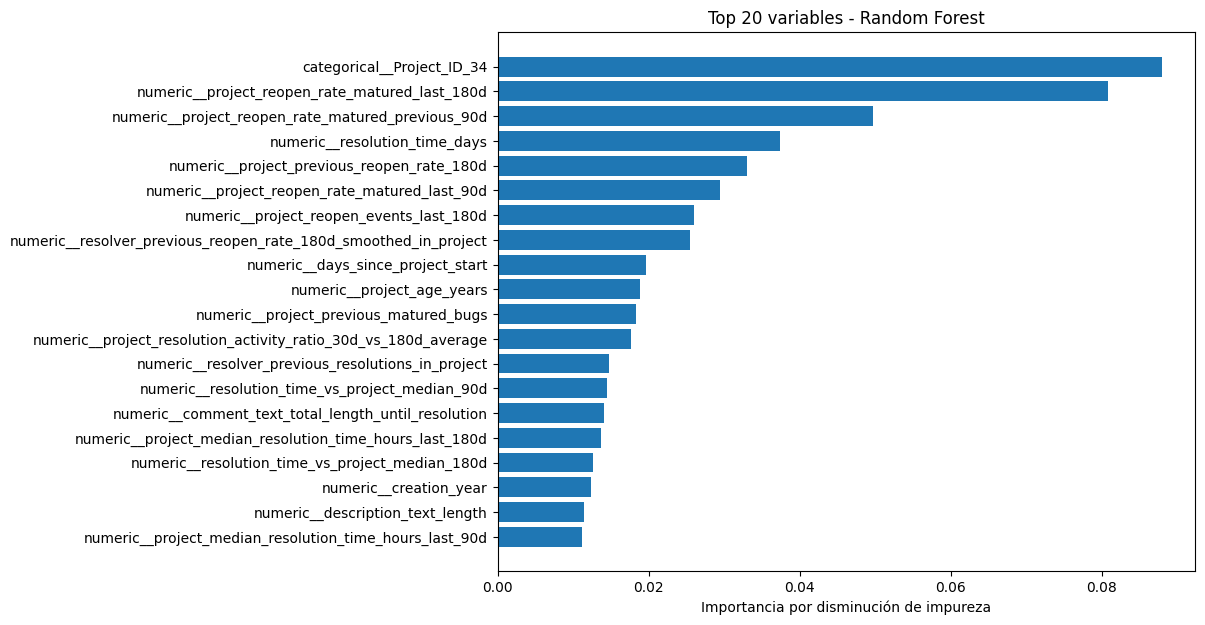

In [34]:
rf_feature_names = rf_preprocessor_final.get_feature_names_out()

rf_importance = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": random_forest_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(rf_importance.head(30))

rf_top_plot = rf_importance.head(20).sort_values("importance")

plt.figure(figsize=(9, 7))
plt.barh(rf_top_plot["feature"], rf_top_plot["importance"])
plt.xlabel("Importancia por disminución de impureza")
plt.title("Top 20 variables - Random Forest")
plt.show()


# 12. LightGBM avanzado

La optimización se realiza en dos etapas y exclusivamente sobre los folds temporales ponderados. Cada ajuste usa *early stopping*. Los mejores candidatos se reevalúan con cinco semillas y el modelo final promedia sus probabilidades.


In [35]:
n_negative_development = int((y_development == 0).sum())
n_positive_development = int((y_development == 1).sum())

base_scale_pos_weight = (
    n_negative_development / n_positive_development
)

smallest_fold_train_size = min(
    len(train_idx)
    for train_idx, _ in cv_splits
)

print("Negativos desarrollo:", n_negative_development)
print("Positivos desarrollo:", n_positive_development)
print(
    "Relación negativos/positivos:",
    round(base_scale_pos_weight, 4),
)
print(
    "Menor tamaño de entrenamiento entre folds:",
    smallest_fold_train_size,
)

LGBM_COMMON_PARAMS = {
    "objective": "binary",
    "metric": "None",
    "n_jobs": N_JOBS,
    "verbosity": -1,
    "subsample_freq": 1,
    "force_col_wise": True,
    "deterministic": True,
}


def lgbm_pr_auc_metric(y_true, y_pred):
    return (
        "pr_auc",
        average_precision_score(
            y_true,
            y_pred,
        ),
        True,
    )


def materialize_lgbm_params(
    search_params,
    n_train,
    random_state,
    n_estimators=None,
):
    params = dict(search_params)

    min_child_fraction = float(
        params.pop(
            "min_child_fraction",
            50 / max(1, len(y_development)),
        )
    )

    min_child_samples = max(
        20,
        int(round(min_child_fraction * n_train)),
    )

    max_depth = int(params.get("max_depth", -1))
    max_leaves_by_depth = (
        127
        if max_depth <= 0
        else min(127, (2 ** max_depth) - 1)
    )
    max_leaves_by_samples = max(
        2,
        int(n_train // min_child_samples),
    )

    requested_num_leaves = int(
        params.get("num_leaves", 31)
    )

    params["num_leaves"] = max(
        2,
        min(
            requested_num_leaves,
            max_leaves_by_depth,
            max_leaves_by_samples,
            127,
        ),
    )

    params["min_child_samples"] = (
        min_child_samples
    )
    params["n_estimators"] = int(
        n_estimators
        if n_estimators is not None
        else LGBM_MAX_BOOSTING_ROUNDS
    )

    params["random_state"] = int(random_state)
    params["bagging_seed"] = int(random_state)
    params["feature_fraction_seed"] = int(
        random_state
    )
    params["data_random_seed"] = int(
        random_state
    )

    return params


def make_lgbm_model(
    search_params,
    n_train,
    random_state,
    n_estimators=None,
):
    return LGBMClassifier(
        **LGBM_COMMON_PARAMS,
        **materialize_lgbm_params(
            search_params=search_params,
            n_train=n_train,
            random_state=random_state,
            n_estimators=n_estimators,
        ),
    )


lgbm_baseline_params = {
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_fraction": (
        50 / max(1, len(y_development))
    ),
    "subsample": 0.80,
    "colsample_bytree": 0.80,
    "max_bin": 255,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "min_split_gain": 0.0,
    "scale_pos_weight": base_scale_pos_weight,
    "cat_smooth": 10.0,
    "cat_l2": 10.0,
}


Negativos desarrollo: 45163
Positivos desarrollo: 6194
Relación negativos/positivos: 7.2914
Menor tamaño de entrenamiento entre folds: 21422


In [36]:
def fit_lgbm_fold(
    search_params,
    fold_train_idx,
    fold_validation_idx,
    random_state,
    collect_importance=False,
):
    (
        X_fold_train,
        fold_future_frames,
        unknown_category_audit,
    ) = prepare_lgbm_native_frames(
        reference_frame=X_development.iloc[
            fold_train_idx
        ],
        other_frames={
            "validation": X_development.iloc[
                fold_validation_idx
            ],
        },
    )

    X_fold_validation = fold_future_frames[
        "validation"
    ]

    model = make_lgbm_model(
        search_params=search_params,
        n_train=len(fold_train_idx),
        random_state=random_state,
    )

    model.fit(
        X_fold_train,
        y_development.iloc[fold_train_idx],
        categorical_feature=categorical_cols,
        eval_set=[
            (
                X_fold_validation,
                y_development.iloc[
                    fold_validation_idx
                ],
            )
        ],
        eval_metric=lgbm_pr_auc_metric,
        callbacks=[
            early_stopping(
                stopping_rounds=(
                    LGBM_EARLY_STOPPING_ROUNDS
                ),
                first_metric_only=True,
                verbose=False,
            ),
            log_evaluation(period=0),
        ],
    )

    best_iteration = int(
        getattr(model, "best_iteration_", 0)
        or materialize_lgbm_params(
            search_params=search_params,
            n_train=len(fold_train_idx),
            random_state=random_state,
        )["n_estimators"]
    )

    validation_score = model.predict_proba(
        X_fold_validation,
        num_iteration=best_iteration,
    )[:, 1]

    importance_frame = None

    if collect_importance:
        gain = model.booster_.feature_importance(
            importance_type="gain"
        ).astype("float64")

        split = model.booster_.feature_importance(
            importance_type="split"
        ).astype("float64")

        gain_total = gain.sum()
        split_total = split.sum()

        importance_frame = pd.DataFrame({
            "feature": feature_cols,
            "importance_gain": gain,
            "importance_split": split,
            "importance_gain_share": (
                gain / gain_total
                if gain_total > 0
                else np.zeros_like(gain)
            ),
            "importance_split_share": (
                split / split_total
                if split_total > 0
                else np.zeros_like(split)
            ),
        })

    del X_fold_train
    del X_fold_validation
    gc.collect()

    return {
        "score": validation_score,
        "best_iteration": best_iteration,
        "importance": importance_frame,
        "unknown_category_audit": (
            unknown_category_audit
        ),
    }


def evaluate_lgbm_params_cv(
    search_params,
    seeds=(RANDOM_STATE,),
    return_oof=False,
    model_name="LightGBM",
    collect_importance=False,
):
    seeds = [int(seed) for seed in seeds]

    seed_fold_scores = {
        seed: []
        for seed in seeds
    }
    seed_oof_scores = {
        seed: np.full(
            len(y_development),
            np.nan,
            dtype="float64",
        )
        for seed in seeds
    }

    ensemble_oof_score = (
        np.full(
            len(y_development),
            np.nan,
            dtype="float64",
        )
        if return_oof
        else None
    )

    ensemble_fold_scores = []
    fold_rows = []
    best_iteration_rows = []
    importance_frames = []
    unknown_category_frames = []

    for fold_number, (
        fold_train_idx,
        fold_validation_idx,
    ) in enumerate(
        cv_splits,
        start=1,
    ):
        fold_seed_predictions = []
        fold_best_iterations = []

        for seed in seeds:
            fold_result = fit_lgbm_fold(
                search_params=search_params,
                fold_train_idx=fold_train_idx,
                fold_validation_idx=(
                    fold_validation_idx
                ),
                random_state=seed,
                collect_importance=(
                    collect_importance
                ),
            )

            fold_score = fold_result["score"]

            seed_oof_scores[seed][
                fold_validation_idx
            ] = fold_score

            fold_pr_auc = average_precision_score(
                y_development.iloc[
                    fold_validation_idx
                ],
                fold_score,
            )

            seed_fold_scores[seed].append(
                fold_pr_auc
            )
            fold_seed_predictions.append(
                fold_score
            )
            fold_best_iterations.append(
                fold_result["best_iteration"]
            )

            best_iteration_rows.append({
                "seed": seed,
                "fold": fold_number,
                "fold_weight": float(
                    TEMPORAL_FOLD_WEIGHTS[
                        fold_number - 1
                    ]
                ),
                "best_iteration": int(
                    fold_result["best_iteration"]
                ),
            })

            if collect_importance:
                importance_frame = (
                    fold_result["importance"]
                    .copy()
                )
                importance_frame["seed"] = seed
                importance_frame[
                    "fold"
                ] = fold_number
                importance_frames.append(
                    importance_frame
                )

            unknown_audit = (
                fold_result[
                    "unknown_category_audit"
                ]
                .copy()
            )
            unknown_audit["seed"] = seed
            unknown_audit["fold"] = fold_number
            unknown_category_frames.append(
                unknown_audit
            )

        ensemble_fold_prediction = np.mean(
            np.vstack(fold_seed_predictions),
            axis=0,
        )

        if return_oof:
            ensemble_oof_score[
                fold_validation_idx
            ] = ensemble_fold_prediction

        ensemble_fold_pr_auc = (
            average_precision_score(
                y_development.iloc[
                    fold_validation_idx
                ],
                ensemble_fold_prediction,
            )
        )

        ensemble_fold_scores.append(
            ensemble_fold_pr_auc
        )

        fold_row = summarize_fold_predictions(
            model_name=model_name,
            y_true=y_development.iloc[
                fold_validation_idx
            ],
            y_score=ensemble_fold_prediction,
            fold_number=fold_number,
        )
        fold_row["fold_weight"] = float(
            TEMPORAL_FOLD_WEIGHTS[
                fold_number - 1
            ]
        )
        fold_row["n_seeds"] = len(seeds)
        fold_row[
            "median_best_iteration"
        ] = float(
            np.median(fold_best_iterations)
        )
        fold_rows.append(fold_row)

    if (
        return_oof
        and np.isnan(
            ensemble_oof_score[
                cv_validation_mask
            ]
        ).any()
    ):
        raise RuntimeError(
            "Quedaron observaciones de validación "
            "sin predicción del ensamble LightGBM."
        )

    seed_weighted_scores = {
        seed: weighted_temporal_average(
            fold_scores
        )
        for seed, fold_scores in (
            seed_fold_scores.items()
        )
    }

    seed_weighted_values = np.asarray(
        list(seed_weighted_scores.values()),
        dtype="float64",
    )

    ensemble_fold_scores_array = np.asarray(
        ensemble_fold_scores,
        dtype="float64",
    )

    ensemble_weighted_pr_auc = (
        weighted_temporal_average(
            ensemble_fold_scores_array
        )
    )

    seed_weighted_std = float(
        np.std(
            seed_weighted_values,
            ddof=1,
        )
        if len(seed_weighted_values) > 1
        else 0.0
    )

    stability_score = float(
        ensemble_weighted_pr_auc
        - LGBM_STABILITY_PENALTY
        * seed_weighted_std
    )

    best_iterations = pd.DataFrame(
        best_iteration_rows
    )

    recommended_n_estimators = int(
        round(
            weighted_median(
                values=best_iterations[
                    "best_iteration"
                ],
                weights=best_iterations[
                    "fold_weight"
                ],
            )
        )
    )

    return {
        "mean_pr_auc": float(
            ensemble_fold_scores_array.mean()
        ),
        "std_pr_auc": float(
            ensemble_fold_scores_array.std(
                ddof=1
            )
            if len(
                ensemble_fold_scores_array
            ) > 1
            else 0.0
        ),
        "weighted_pr_auc": float(
            ensemble_weighted_pr_auc
        ),
        "fold_pr_auc": (
            ensemble_fold_scores_array.tolist()
        ),
        "fold_weights": (
            TEMPORAL_FOLD_WEIGHTS.tolist()
        ),
        "oof_score": ensemble_oof_score,
        "fold_results": pd.DataFrame(
            fold_rows
        ),
        "seed_weighted_pr_auc": (
            seed_weighted_scores
        ),
        "seed_weighted_pr_auc_mean": float(
            seed_weighted_values.mean()
        ),
        "seed_weighted_pr_auc_std": (
            seed_weighted_std
        ),
        "stability_score": stability_score,
        "best_iterations": best_iterations,
        "recommended_n_estimators": (
            recommended_n_estimators
        ),
        "importance_rows": (
            pd.concat(
                importance_frames,
                ignore_index=True,
            )
            if importance_frames
            else pd.DataFrame()
        ),
        "unknown_category_audit": (
            pd.concat(
                unknown_category_frames,
                ignore_index=True,
            )
            if unknown_category_frames
            else pd.DataFrame()
        ),
    }


lgbm_baseline_cv = evaluate_lgbm_params_cv(
    search_params=lgbm_baseline_params,
    seeds=(RANDOM_STATE,),
    return_oof=False,
    model_name="LightGBM baseline",
)

print(
    "PR-AUC ponderada CV LightGBM base:",
    round(
        lgbm_baseline_cv[
            "weighted_pr_auc"
        ],
        6,
    ),
)
print(
    "Mejores iteraciones base por fold:",
    lgbm_baseline_cv[
        "best_iterations"
    ]["best_iteration"].tolist(),
)


/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(
/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(
/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(
/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(
/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical w

PR-AUC ponderada CV LightGBM base: 0.253606
Mejores iteraciones base por fold: [262, 297, 184]


In [37]:
def structure_params_from_values(values):
    return {
        "learning_rate": float(
            values["learning_rate"]
        ),
        "max_depth": int(
            values["max_depth"]
        ),
        "num_leaves": int(
            values["num_leaves"]
        ),
        "min_child_fraction": float(
            values["min_child_fraction"]
        ),
        "subsample": float(
            values["subsample"]
        ),
        "colsample_bytree": float(
            values["colsample_bytree"]
        ),
        "max_bin": int(
            values["max_bin"]
        ),
        "reg_alpha": 0.0,
        "reg_lambda": 1.0,
        "min_split_gain": 0.0,
        "scale_pos_weight": (
            base_scale_pos_weight
        ),
        "cat_smooth": 10.0,
        "cat_l2": 10.0,
    }


def lgbm_structure_objective(trial):
    trial_values = {
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.005,
            0.12,
            log=True,
        ),
        "max_depth": trial.suggest_int(
            "max_depth",
            4,
            10,
        ),
        "num_leaves": trial.suggest_int(
            "num_leaves",
            8,
            127,
        ),
        "min_child_fraction": (
            trial.suggest_float(
                "min_child_fraction",
                0.001,
                0.03,
                log=True,
            )
        ),
        "subsample": trial.suggest_float(
            "subsample",
            0.65,
            1.00,
        ),
        "colsample_bytree": (
            trial.suggest_float(
                "colsample_bytree",
                0.45,
                1.00,
            )
        ),
        "max_bin": trial.suggest_categorical(
            "max_bin",
            [31, 63, 127, 255],
        ),
    }

    params = structure_params_from_values(
        trial_values
    )

    effective_smallest = (
        materialize_lgbm_params(
            search_params=params,
            n_train=smallest_fold_train_size,
            random_state=RANDOM_STATE,
        )
    )

    trial.set_user_attr(
        "effective_num_leaves_smallest_fold",
        int(effective_smallest["num_leaves"]),
    )
    trial.set_user_attr(
        "effective_min_child_samples_smallest_fold",
        int(
            effective_smallest[
                "min_child_samples"
            ]
        ),
    )

    result = evaluate_lgbm_params_cv(
        search_params=params,
        seeds=(RANDOM_STATE,),
        return_oof=False,
        model_name="LightGBM estructura",
    )

    trial.set_user_attr(
        "recommended_n_estimators",
        int(result["recommended_n_estimators"]),
    )

    return result["weighted_pr_auc"]


lgbm_structure_study = optuna.create_study(
    study_name=(
        f"lgbm_structure_{MODELING_VARIANT}_"
        f"{EXPERIMENT_FINGERPRINT}"
    ),
    storage=OPTUNA_STORAGE_URL,
    load_if_exists=True,
    direction="maximize",
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE,
    ),
)

optimize_study_to_total(
    study=lgbm_structure_study,
    objective=lgbm_structure_objective,
    target_complete_trials=(
        LGBM_STRUCTURE_N_TRIALS
    ),
)

best_lgbm_structure_params = (
    structure_params_from_values(
        lgbm_structure_study.best_params
    )
)

structure_fingerprint = hashlib.sha256(
    json.dumps(
        best_lgbm_structure_params,
        sort_keys=True,
    ).encode("utf-8")
).hexdigest()[:10]


def regularized_params_from_values(values):
    params = dict(
        best_lgbm_structure_params
    )

    params.update({
        "reg_alpha": float(
            values["reg_alpha"]
        ),
        "reg_lambda": float(
            values["reg_lambda"]
        ),
        "min_split_gain": float(
            values["min_split_gain"]
        ),
        "scale_pos_weight": float(
            values["scale_pos_weight"]
        ),
        "cat_smooth": float(
            values["cat_smooth"]
        ),
        "cat_l2": float(
            values["cat_l2"]
        ),
    })

    return params


def lgbm_regularization_objective(trial):
    trial_values = {
        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-5,
            20.0,
            log=True,
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-5,
            20.0,
            log=True,
        ),
        "min_split_gain": (
            trial.suggest_float(
                "min_split_gain",
                0.0,
                0.30,
            )
        ),
        "scale_pos_weight": (
            trial.suggest_float(
                "scale_pos_weight",
                1.0,
                max(
                    1.01,
                    base_scale_pos_weight
                    * 1.75,
                ),
                log=True,
            )
        ),
        "cat_smooth": trial.suggest_float(
            "cat_smooth",
            1.0,
            100.0,
            log=True,
        ),
        "cat_l2": trial.suggest_float(
            "cat_l2",
            0.05,
            50.0,
            log=True,
        ),
    }

    params = regularized_params_from_values(
        trial_values
    )

    result = evaluate_lgbm_params_cv(
        search_params=params,
        seeds=(RANDOM_STATE,),
        return_oof=False,
        model_name="LightGBM regularización",
    )

    trial.set_user_attr(
        "recommended_n_estimators",
        int(result["recommended_n_estimators"]),
    )

    return result["weighted_pr_auc"]


lgbm_regularization_study = (
    optuna.create_study(
        study_name=(
            f"lgbm_regularization_"
            f"{MODELING_VARIANT}_"
            f"{EXPERIMENT_FINGERPRINT}_"
            f"{structure_fingerprint}"
        ),
        storage=OPTUNA_STORAGE_URL,
        load_if_exists=True,
        direction="maximize",
        sampler=optuna.samplers.TPESampler(
            seed=RANDOM_STATE + 1,
        ),
    )
)

optimize_study_to_total(
    study=lgbm_regularization_study,
    objective=lgbm_regularization_objective,
    target_complete_trials=(
        LGBM_REGULARIZATION_N_TRIALS
    ),
)

best_lgbm_regularized_params = (
    regularized_params_from_values(
        lgbm_regularization_study.best_params
    )
)

print(
    "Mejor PR-AUC ponderada - estructura:",
    lgbm_structure_study.best_value,
)
print(
    "Mejor PR-AUC ponderada - regularización:",
    lgbm_regularization_study.best_value,
)


/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(
/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(
/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(
/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(
/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical w

Estudio lgbm_structure_base_5f07106769c5: 50/50 trials completos.


/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(
/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(
/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(
/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(
/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical w

Estudio lgbm_regularization_base_5f07106769c5_171eb8ae3a: 30/30 trials completos.
Mejor PR-AUC ponderada - estructura: 0.263527646444925
Mejor PR-AUC ponderada - regularización: 0.265639681120276


In [38]:
def params_json(params):
    return json.dumps(
        params,
        sort_keys=True,
        ensure_ascii=False,
    )


candidate_records = [
    {
        "candidate": "baseline",
        "params": lgbm_baseline_params,
    },
    {
        "candidate": "best_structure",
        "params": best_lgbm_structure_params,
    },
]

complete_regularization_trials = [
    trial
    for trial in lgbm_regularization_study.trials
    if (
        trial.state
        == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
    )
]

top_regularization_trials = sorted(
    complete_regularization_trials,
    key=lambda trial: trial.value,
    reverse=True,
)[:LGBM_REEVALUATION_TOP_N]

for rank, trial in enumerate(
    top_regularization_trials,
    start=1,
):
    candidate_records.append({
        "candidate": (
            f"regularization_rank_{rank}"
        ),
        "params": (
            regularized_params_from_values(
                trial.params
            )
        ),
    })

# Elimina configuraciones duplicadas.
unique_candidate_records = []
seen_param_keys = set()

for record in candidate_records:
    key = params_json(record["params"])

    if key in seen_param_keys:
        continue

    seen_param_keys.add(key)
    record = dict(record)
    record["params_key"] = hashlib.sha256(
        key.encode("utf-8")
    ).hexdigest()[:12]
    unique_candidate_records.append(record)

candidate_cache_path = (
    RESULTS_DIR
    / (
        "lgbm_multiseed_candidates_"
        f"{EXPERIMENT_FINGERPRINT}.csv"
    )
)

if candidate_cache_path.exists():
    candidate_cache = pd.read_csv(
        candidate_cache_path
    )
else:
    candidate_cache = pd.DataFrame()

candidate_result_rows = []

for record in unique_candidate_records:
    cached = pd.DataFrame()

    if not candidate_cache.empty:
        cached = candidate_cache.loc[
            candidate_cache["params_key"].eq(
                record["params_key"]
            )
        ]

    if not cached.empty:
        candidate_result_rows.append(
            cached.iloc[0].to_dict()
        )
        print(
            "Candidato recuperado de caché:",
            record["candidate"],
        )
        continue

    evaluation = evaluate_lgbm_params_cv(
        search_params=record["params"],
        seeds=LGBM_ENSEMBLE_SEEDS,
        return_oof=False,
        model_name=record["candidate"],
    )

    result_row = {
        "candidate": record["candidate"],
        "params_key": record["params_key"],
        "params_json": params_json(
            record["params"]
        ),
        "cv_pr_auc_mean": (
            evaluation["mean_pr_auc"]
        ),
        "cv_pr_auc_std": (
            evaluation["std_pr_auc"]
        ),
        "cv_pr_auc_weighted": (
            evaluation["weighted_pr_auc"]
        ),
        "seed_weighted_pr_auc_mean": (
            evaluation[
                "seed_weighted_pr_auc_mean"
            ]
        ),
        "seed_weighted_pr_auc_std": (
            evaluation[
                "seed_weighted_pr_auc_std"
            ]
        ),
        "stability_score": (
            evaluation["stability_score"]
        ),
        "recommended_n_estimators": (
            evaluation[
                "recommended_n_estimators"
            ]
        ),
        "fold_1_pr_auc": (
            evaluation["fold_pr_auc"][0]
        ),
        "fold_2_pr_auc": (
            evaluation["fold_pr_auc"][1]
        ),
        "fold_3_pr_auc": (
            evaluation["fold_pr_auc"][2]
        ),
        "n_seeds": len(
            LGBM_ENSEMBLE_SEEDS
        ),
    }

    candidate_result_rows.append(
        result_row
    )

    candidate_cache = pd.concat(
        [
            candidate_cache,
            pd.DataFrame([result_row]),
        ],
        ignore_index=True,
    )

    candidate_cache.to_csv(
        candidate_cache_path,
        index=False,
        encoding="utf-8-sig",
    )

lgbm_candidate_results = (
    pd.DataFrame(candidate_result_rows)
    .drop_duplicates(
        subset=["params_key"],
        keep="last",
    )
    .sort_values(
        [
            "stability_score",
            "cv_pr_auc_weighted",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(lgbm_candidate_results)

selected_candidate_row = (
    lgbm_candidate_results.iloc[0]
)

lgbm_selected_name = str(
    selected_candidate_row["candidate"]
)
lgbm_selected_params = json.loads(
    selected_candidate_row["params_json"]
)

print(
    "LightGBM seleccionado por desempeño "
    "ponderado y estabilidad:",
    lgbm_selected_name,
)
print(
    "Score de selección:",
    selected_candidate_row[
        "stability_score"
    ],
)


/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(
/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(
/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(
/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(
/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical w

,candidate,params_key,params_json,cv_pr_auc_mean,cv_pr_auc_std,cv_pr_auc_weighted,seed_weighted_pr_auc_mean,seed_weighted_pr_auc_std,stability_score,recommended_n_estimators,fold_1_pr_auc,fold_2_pr_auc,fold_3_pr_auc,n_seeds
0,regularization_rank_5,32f24b59a3aa,"{""cat_l2"": 15.298041553286085, ""cat_smooth"": 8...",0.290330,0.073385,0.267912,0.258574,0.003367,0.266229,265,0.353663,0.307419,0.209908,5
1,regularization_rank_2,87b41f3146e9,"{""cat_l2"": 12.738296699453352, ""cat_smooth"": 6...",0.289068,0.071394,0.267274,0.257566,0.004424,0.265062,188,0.349179,0.307870,0.210154,5
2,best_structure,171eb8ae3a8c,"{""cat_l2"": 10.0, ""cat_smooth"": 10.0, ""colsampl...",0.287193,0.069626,0.265956,0.258374,0.003487,0.264212,370,0.344898,0.306821,0.209860,5
3,baseline,ee6f999f2167,"{""cat_l2"": 10.0, ""cat_smooth"": 10.0, ""colsampl...",0.285370,0.063284,0.266037,0.255923,0.005308,0.263383,188,0.340303,0.299636,0.216170,5
4,regularization_rank_4,609d5cadbd6f,"{""cat_l2"": 26.604694592843774, ""cat_smooth"": 9...",0.287954,0.072594,0.265800,0.257708,0.004856,0.263372,176,0.348711,0.307588,0.207562,5
5,regularization_rank_1,20a3d3035838,"{""cat_l2"": 20.504420641941486, ""cat_smooth"": 2...",0.286318,0.072564,0.264227,0.254217,0.003642,0.262406,231,0.354041,0.295185,0.209727,5
6,regularization_rank_3,133b99a5ecbf,"{""cat_l2"": 3.914623692979072, ""cat_smooth"": 2....",0.281621,0.063052,0.262383,0.255038,0.004842,0.259962,209,0.339002,0.291740,0.214121,5


LightGBM seleccionado por desempeño ponderado y estabilidad: regularization_rank_5
Score de selección: 0.26622895267086794


In [39]:
lgbm_selected_cv = evaluate_lgbm_params_cv(
    search_params=lgbm_selected_params,
    seeds=LGBM_ENSEMBLE_SEEDS,
    return_oof=True,
    model_name="LightGBM",
    collect_importance=True,
)

lgbm_oof_score = (
    lgbm_selected_cv["oof_score"]
)
lgbm_cv_results = (
    lgbm_selected_cv["fold_results"]
)

lgbm_threshold, lgbm_threshold_table = (
    select_threshold_by_f1(
        y_true=y_development.iloc[
            np.flatnonzero(
                cv_validation_mask
            )
        ],
        y_score=lgbm_oof_score[
            cv_validation_mask
        ],
    )
)

(
    X_development_lgbm,
    lgbm_future_frames,
    lgbm_unknown_category_audit,
) = prepare_lgbm_native_frames(
    reference_frame=X_development,
    other_frames={"test": X_test},
)

X_test_lgbm = lgbm_future_frames[
    "test"
]

lgbm_final_n_estimators = int(
    lgbm_selected_cv[
        "recommended_n_estimators"
    ]
)

lightgbm_models = []
lgbm_seed_test_predictions = []
lgbm_final_importance_frames = []

for seed in LGBM_ENSEMBLE_SEEDS:
    model = make_lgbm_model(
        search_params=lgbm_selected_params,
        n_train=len(y_development),
        random_state=seed,
        n_estimators=(
            lgbm_final_n_estimators
        ),
    )

    model.fit(
        X_development_lgbm,
        y_development,
        categorical_feature=categorical_cols,
    )

    seed_test_score = model.predict_proba(
        X_test_lgbm
    )[:, 1]

    lgbm_seed_test_predictions.append(
        seed_test_score
    )
    lightgbm_models.append(model)

    gain = model.booster_.feature_importance(
        importance_type="gain"
    ).astype("float64")
    split = model.booster_.feature_importance(
        importance_type="split"
    ).astype("float64")

    gain_total = gain.sum()
    split_total = split.sum()

    importance_frame = pd.DataFrame({
        "feature": feature_cols,
        "seed": seed,
        "importance_gain": gain,
        "importance_split": split,
        "importance_gain_share": (
            gain / gain_total
            if gain_total > 0
            else np.zeros_like(gain)
        ),
        "importance_split_share": (
            split / split_total
            if split_total > 0
            else np.zeros_like(split)
        ),
    })

    lgbm_final_importance_frames.append(
        importance_frame
    )

lgbm_test_score = np.mean(
    np.vstack(
        lgbm_seed_test_predictions
    ),
    axis=0,
)

# Alias solo para mantener compatibilidad con código auxiliar.
lightgbm_model = lightgbm_models[0]

lgbm_missing_audit = pd.DataFrame({
    "development": (
        X_development_lgbm.isna().sum()
    ),
    "test": X_test_lgbm.isna().sum(),
})

unexpected_development_missing = set(
    lgbm_missing_audit.loc[
        lgbm_missing_audit[
            "development"
        ] > 0
    ].index
) - set(
    allowed_missing_cols
)

if unexpected_development_missing:
    raise ValueError(
        "LightGBM presenta faltantes "
        "inesperados en desarrollo: "
        f"{sorted(unexpected_development_missing)}"
    )

print(
    "PR-AUC ponderada CV del ensamble LightGBM:",
    lgbm_selected_cv["weighted_pr_auc"],
)
print(
    "Desvío entre semillas:",
    lgbm_selected_cv[
        "seed_weighted_pr_auc_std"
    ],
)
print(
    "Árboles finales recomendados:",
    lgbm_final_n_estimators,
)
print(
    "Umbral temporal LightGBM:",
    round(lgbm_threshold, 6),
)
display(lgbm_cv_results)
display(
    lgbm_unknown_category_audit.loc[
        lgbm_unknown_category_audit[
            "categorias_desconocidas"
        ] > 0
    ]
)


/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(
/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(
/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(
/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pd.Categorical(
/tmp/ipykernel_41/1800814409.py:60: Pandas4Warning: Constructing a Categorical w

PR-AUC ponderada CV del ensamble LightGBM: 0.26791229402768957
Desvío entre semillas: 0.0033666827136433035
Árboles finales recomendados: 265
Umbral temporal LightGBM: 0.301058


,model,fold,n,prevalence,pr_auc,roc_auc,fold_weight,n_seeds,median_best_iteration
0,LightGBM,1,7703,0.145787,0.353663,0.789914,0.2,5,305.0
1,LightGBM,2,7703,0.122290,0.307419,0.771382,0.3,5,353.0
2,LightGBM,3,7703,0.102947,0.209908,0.714068,0.5,5,197.0


,split,variable,categorias_desconocidas
1,test,Status_Before_First_Resolution,514
3,test,First_Resolution_Status,4


In [40]:
lgbm_results_05 = evaluate_model(
    model_name="LightGBM - threshold 0.50",
    y_true=y_test,
    y_score=lgbm_test_score,
    threshold=0.5,
)

lgbm_results_selected = evaluate_model(
    model_name="LightGBM - threshold temporal CV",
    y_true=y_test,
    y_score=lgbm_test_score,
    threshold=lgbm_threshold,
)

display(
    score_distribution(
        oof_score=lgbm_oof_score[
            cv_validation_mask
        ],
        test_score=lgbm_test_score,
    )
)

display(pd.DataFrame([
    lgbm_results_05,
    lgbm_results_selected,
]))

display(
    confusion_matrix_table(
        y_true=y_test,
        y_score=lgbm_test_score,
        threshold=lgbm_threshold,
    )
)


,temporal_validation,test
count,23109.000000,13373.000000
mean,0.240997,0.147319
std,0.210688,0.120357
min,0.001694,0.009560
1%,0.004584,0.016933
5%,0.011722,0.024893
10%,0.020235,0.032092
25%,0.047130,0.052906
50%,0.175108,0.099550
75%,0.414512,0.226607


,model,threshold,test_prevalence,pr_auc,roc_auc,precision_1,recall_1,f1_1,balanced_accuracy,precision_at_10pct,recall_at_10pct,predicted_positive_rate,tn,fp,fn,tp
0,LightGBM - threshold 0.50,0.500000,0.055036,0.137162,0.718733,0.25000,0.036685,0.063981,0.515138,0.142003,0.258152,0.008076,12556,81,709,27
1,LightGBM - threshold temporal CV,0.301058,0.055036,0.137162,0.718733,0.13719,0.338315,0.195218,0.607197,0.142003,0.258152,0.135721,11071,1566,487,249


,Predicho no reabierto,Predicho reabierto
Real no reabierto,11071,1566
Real reabierto,487,249


### Estabilidad de la importancia de variables

La importancia se resume sobre todos los folds y semillas. Se informa la proporción media de ganancia, su variabilidad y la frecuencia con la que cada predictor aparece entre las veinte variables principales.


,feature,mean_gain_share,std_gain_share,mean_split_share,std_split_share,top_20_frequency,mean_gain_rank,evaluated_models
0,Project_ID,0.096468,0.069326,0.002549,0.001643,0.733333,10.266667,15
1,project_reopen_events_last_180d,0.046214,0.046826,0.014291,0.002345,1.000000,8.333333,15
2,resolution_time_days,0.031766,0.004593,0.026471,0.004104,1.000000,2.933333,15
3,project_resolution_activity_ratio_30d_vs_180d_...,0.026080,0.011024,0.015640,0.000984,0.666667,10.266667,15
4,description_text_length,0.025375,0.008457,0.036026,0.009141,0.933333,5.733333,15
5,title_length,0.022411,0.007637,0.033753,0.007561,0.933333,8.000000,15
6,Priority_At_First_Resolution,0.020533,0.006537,0.013349,0.002755,0.800000,10.933333,15
7,resolver_previous_resolutions_in_project,0.020156,0.002379,0.025085,0.002961,1.000000,6.866667,15
8,comment_text_total_length_until_resolution,0.017951,0.003560,0.020959,0.003543,1.000000,10.000000,15
9,resolution_time_vs_project_median_90d,0.017450,0.002960,0.021044,0.001761,1.000000,10.733333,15


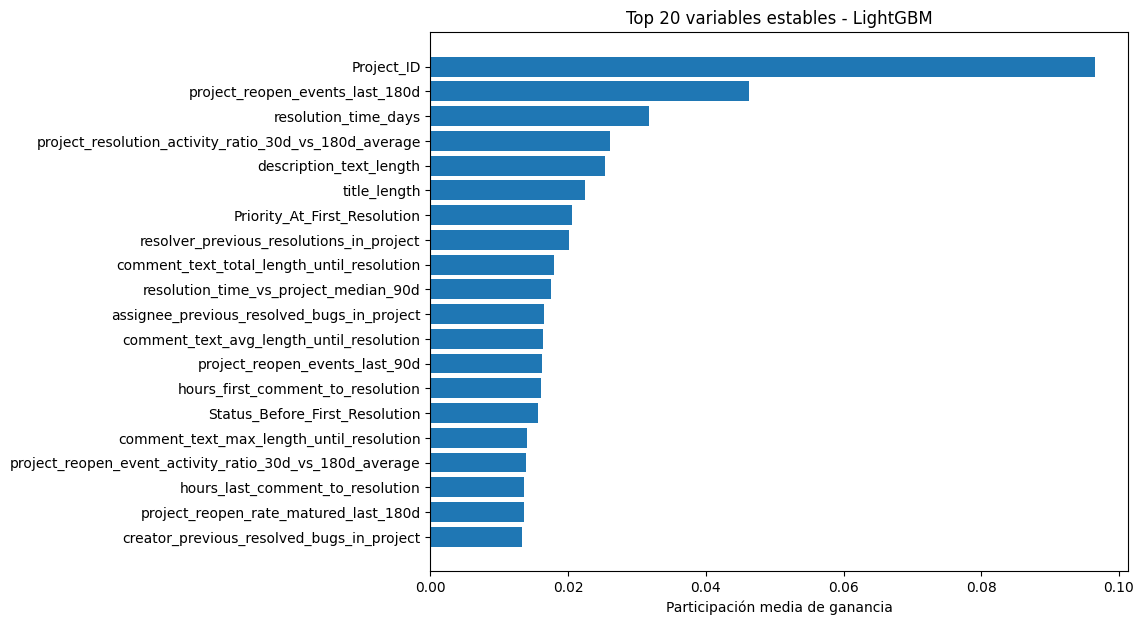

In [41]:
lgbm_cv_importance_rows = (
    lgbm_selected_cv[
        "importance_rows"
    ].copy()
)

if lgbm_cv_importance_rows.empty:
    raise RuntimeError(
        "No se registraron importancias "
        "de LightGBM en validación."
    )

lgbm_cv_importance_rows[
    "gain_rank"
] = (
    lgbm_cv_importance_rows
    .groupby(
        ["seed", "fold"],
        observed=True,
    )["importance_gain_share"]
    .rank(
        method="min",
        ascending=False,
    )
)

lgbm_cv_importance_rows[
    "is_top_20"
] = (
    lgbm_cv_importance_rows[
        "gain_rank"
    ] <= 20
).astype("int8")

lgbm_importance_stability = (
    lgbm_cv_importance_rows
    .groupby(
        "feature",
        observed=True,
        as_index=False,
    )
    .agg(
        mean_gain_share=(
            "importance_gain_share",
            "mean",
        ),
        std_gain_share=(
            "importance_gain_share",
            "std",
        ),
        mean_split_share=(
            "importance_split_share",
            "mean",
        ),
        std_split_share=(
            "importance_split_share",
            "std",
        ),
        top_20_frequency=(
            "is_top_20",
            "mean",
        ),
        mean_gain_rank=(
            "gain_rank",
            "mean",
        ),
        evaluated_models=(
            "gain_rank",
            "size",
        ),
    )
    .sort_values(
        [
            "mean_gain_share",
            "top_20_frequency",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

lgbm_final_importance_rows = pd.concat(
    lgbm_final_importance_frames,
    ignore_index=True,
)

lgbm_importance = (
    lgbm_final_importance_rows
    .groupby(
        "feature",
        observed=True,
        as_index=False,
    )
    .agg(
        importance_gain=(
            "importance_gain",
            "mean",
        ),
        importance_split=(
            "importance_split",
            "mean",
        ),
        importance_gain_share=(
            "importance_gain_share",
            "mean",
        ),
        importance_gain_share_std=(
            "importance_gain_share",
            "std",
        ),
    )
    .sort_values(
        "importance_gain_share",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    lgbm_importance_stability.head(30)
)

lgbm_top_plot = (
    lgbm_importance_stability
    .head(20)
    .sort_values("mean_gain_share")
)

plt.figure(figsize=(9, 7))
plt.barh(
    lgbm_top_plot["feature"],
    lgbm_top_plot["mean_gain_share"],
)
plt.xlabel(
    "Participación media de ganancia"
)
plt.title(
    "Top 20 variables estables - LightGBM"
)
plt.show()


# 13. Comparación de modelos

Las métricas de validación resumen los bloques temporales expansivos. Las métricas finales corresponden exclusivamente al período de test posterior.

In [42]:
selected_threshold_results = pd.DataFrame([
    dummy_results,
    logistic_results_selected,
    rf_results_selected,
    lgbm_results_selected,
]).sort_values("pr_auc", ascending=False)

threshold_05_results = pd.DataFrame([
    dummy_results,
    logistic_results_05,
    rf_results_05,
    lgbm_results_05,
]).sort_values("pr_auc", ascending=False)

cv_results = pd.concat(
    [
        logistic_cv_results,
        rf_cv_results,
        lgbm_cv_results,
    ],
    ignore_index=True,
)

fold_weight_map = {
    fold_number: float(weight)
    for fold_number, weight in enumerate(
        TEMPORAL_FOLD_WEIGHTS,
        start=1,
    )
}

cv_results["fold_weight"] = (
    cv_results["fold"].map(fold_weight_map)
)

if cv_results["fold_weight"].isna().any():
    raise ValueError(
        "Hay resultados de validación sin peso temporal asignado."
    )

cv_summary_rows = []

for model_name, group in cv_results.groupby(
    "model",
    observed=True,
):
    group = group.sort_values("fold")
    weights = group["fold_weight"].to_numpy(dtype=float)
    weights = weights / weights.sum()

    cv_summary_rows.append({
        "model": model_name,
        "folds": int(group["fold"].nunique()),
        "mean_pr_auc": float(group["pr_auc"].mean()),
        "std_pr_auc": float(group["pr_auc"].std(ddof=1)),
        "weighted_pr_auc": float(
            np.average(
                group["pr_auc"].to_numpy(dtype=float),
                weights=weights,
            )
        ),
        "mean_roc_auc": float(group["roc_auc"].mean()),
        "std_roc_auc": float(group["roc_auc"].std(ddof=1)),
        "weighted_roc_auc": weighted_temporal_average(
            group["roc_auc"].to_numpy(dtype=float)
        ),
        "fold_weights": weights.tolist(),
    })

cv_summary = (
    pd.DataFrame(cv_summary_rows)
    .sort_values(
        ["weighted_pr_auc", "weighted_roc_auc"],
        ascending=False,
    )
    .reset_index(drop=True)
)

print("Pesos temporales comunes:", TEMPORAL_FOLD_WEIGHTS)
print("Resultados de validación temporal expansiva")
display(cv_summary)

print("Resultados finales con umbrales de validación temporal")
display(selected_threshold_results)

print("Resultados finales con umbral 0.50")
display(threshold_05_results)


Pesos temporales comunes: [0.2 0.3 0.5]
Resultados de validación temporal expansiva


,model,folds,mean_pr_auc,std_pr_auc,weighted_pr_auc,mean_roc_auc,std_roc_auc,weighted_roc_auc,fold_weights
0,LightGBM,3,0.290330,0.073385,0.267912,0.758455,0.039541,0.746432,"[0.2, 0.3, 0.5]"
1,Random Forest,3,0.248613,0.047895,0.234175,0.737956,0.022557,0.731102,"[0.2, 0.3, 0.5]"
2,Logistic Regression,3,0.203883,0.028240,0.196417,0.655174,0.041392,0.666883,"[0.2, 0.3, 0.5]"


Resultados finales con umbrales de validación temporal


,model,threshold,test_prevalence,pr_auc,roc_auc,precision_1,recall_1,f1_1,balanced_accuracy,precision_at_10pct,recall_at_10pct,predicted_positive_rate,tn,fp,fn,tp
3,LightGBM - threshold temporal CV,0.301058,0.055036,0.137162,0.718733,0.137190,0.338315,0.195218,0.607197,0.142003,0.258152,0.135721,11071,1566,487,249
2,Random Forest - threshold temporal CV,0.577804,0.055036,0.120137,0.694558,0.193416,0.063859,0.096016,0.524174,0.142003,0.258152,0.018171,12441,196,689,47
1,Logistic Regression - threshold temporal CV,0.563591,0.055036,0.109295,0.707415,0.120683,0.413043,0.186790,0.618882,0.126308,0.229620,0.188365,10422,2215,432,304
0,Dummy prior,0.500000,0.055036,0.055036,0.500000,0.000000,0.000000,0.000000,0.500000,0.092676,0.168478,0.000000,12637,0,736,0


Resultados finales con umbral 0.50


,model,threshold,test_prevalence,pr_auc,roc_auc,precision_1,recall_1,f1_1,balanced_accuracy,precision_at_10pct,recall_at_10pct,predicted_positive_rate,tn,fp,fn,tp
3,LightGBM - threshold 0.50,0.5,0.055036,0.137162,0.718733,0.250000,0.036685,0.063981,0.515138,0.142003,0.258152,0.008076,12556,81,709,27
2,Random Forest - threshold 0.50,0.5,0.055036,0.120137,0.694558,0.137052,0.270380,0.181901,0.585614,0.142003,0.258152,0.108577,11384,1253,537,199
1,Logistic Regression - threshold 0.50,0.5,0.055036,0.109295,0.707415,0.120382,0.531250,0.196285,0.652584,0.126308,0.229620,0.242877,9780,2857,345,391
0,Dummy prior,0.5,0.055036,0.055036,0.500000,0.000000,0.000000,0.000000,0.500000,0.092676,0.168478,0.000000,12637,0,736,0


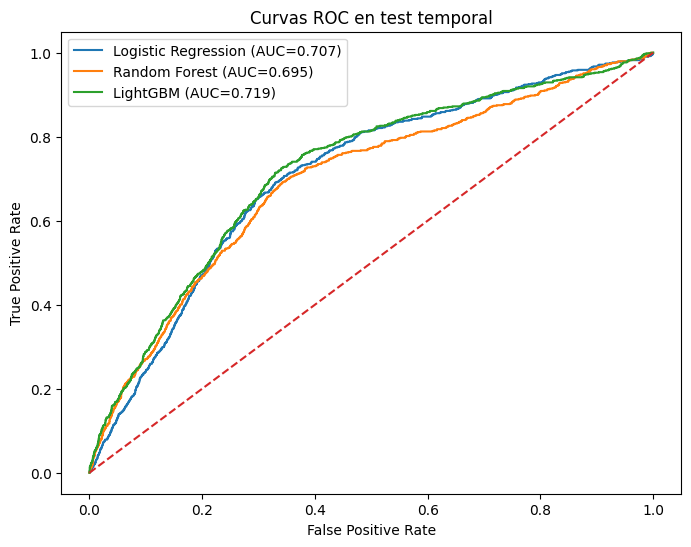

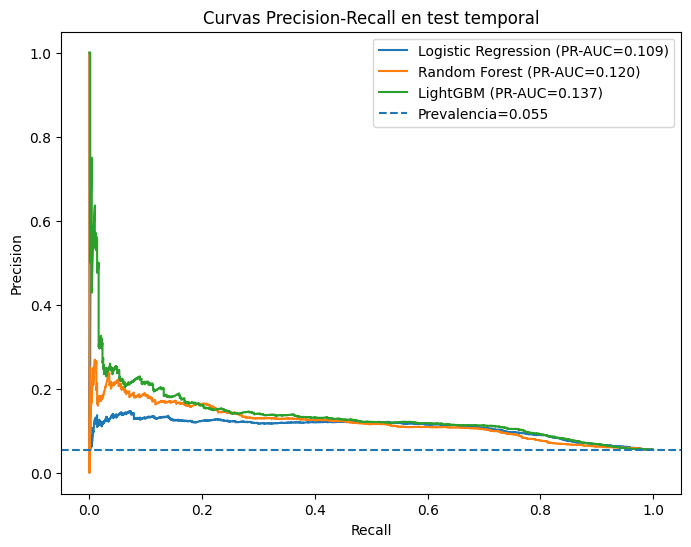

In [43]:
test_scores = {
    "Logistic Regression": logistic_test_score,
    "Random Forest": rf_test_score,
    "LightGBM": lgbm_test_score,
}

selected_thresholds = {
    "Logistic Regression": logistic_threshold,
    "Random Forest": rf_threshold,
    "LightGBM": lgbm_threshold,
}

plt.figure(figsize=(8, 6))

for model_name, score in test_scores.items():
    fpr, tpr, _ = roc_curve(y_test, score)
    plt.plot(
        fpr,
        tpr,
        label=(
            f"{model_name} "
            f"(AUC={roc_auc_score(y_test, score):.3f})"
        ),
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC en test temporal")
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))

for model_name, score in test_scores.items():
    precision, recall, _ = precision_recall_curve(y_test, score)
    plt.plot(
        recall,
        precision,
        label=(
            f"{model_name} "
            f"(PR-AUC={average_precision_score(y_test, score):.3f})"
        ),
    )

plt.axhline(
    y=float(y_test.mean()),
    linestyle="--",
    label=f"Prevalencia={y_test.mean():.3f}",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision-Recall en test temporal")
plt.legend()
plt.show()


### Selección operativa por porcentaje de bugs revisados

Para cada modelo se elige mediante las predicciones fuera de muestra de los folds temporales qué proporción de bugs conviene revisar. El porcentaje seleccionado se congela y luego se evalúa en test.


In [44]:
oof_scores_for_top_k = {
    "Logistic Regression": (
        logistic_oof_score[
            cv_validation_mask
        ]
    ),
    "Random Forest": (
        rf_oof_score[
            cv_validation_mask
        ]
    ),
    "LightGBM": (
        lgbm_oof_score[
            cv_validation_mask
        ]
    ),
}

y_oof_for_top_k = y_development.iloc[
    np.flatnonzero(cv_validation_mask)
].reset_index(drop=True)

top_k_selection_rows = []
top_k_candidate_tables = []
top_k_test_rows = []

for model_name, oof_score in (
    oof_scores_for_top_k.items()
):
    selected_fraction, candidate_table = (
        select_top_fraction_by_f1(
            y_true=y_oof_for_top_k,
            y_score=oof_score,
        )
    )

    candidate_table = (
        candidate_table.copy()
    )
    candidate_table.insert(
        0,
        "model",
        model_name,
    )
    top_k_candidate_tables.append(
        candidate_table
    )

    selected_validation_row = (
        candidate_table.loc[
            candidate_table[
                "fraction"
            ].eq(selected_fraction)
        ]
        .iloc[0]
        .to_dict()
    )

    top_k_selection_rows.append(
        selected_validation_row
    )

    test_metrics = top_fraction_metrics(
        y_true=y_test,
        y_score=test_scores[model_name],
        fraction=selected_fraction,
    )
    test_metrics["model"] = model_name
    top_k_test_rows.append(
        test_metrics
    )

top_k_candidate_results = pd.concat(
    top_k_candidate_tables,
    ignore_index=True,
)

top_k_selection_summary = pd.DataFrame(
    top_k_selection_rows
).sort_values(
    "f1",
    ascending=False,
)

top_k_test_results = pd.DataFrame(
    top_k_test_rows
).sort_values(
    "f1",
    ascending=False,
)

print(
    "Selección de porcentaje operativo "
    "mediante validación temporal"
)
display(top_k_selection_summary)

print(
    "Evaluación en test del porcentaje "
    "seleccionado previamente"
)
display(top_k_test_results)


Selección de porcentaje operativo mediante validación temporal


,model,fraction,n_selected,precision,recall,f1,lift
2,LightGBM,0.2,4622,0.278451,0.450315,0.344118,2.251477
1,Random Forest,0.2,4622,0.257032,0.415675,0.317647,2.078287
0,Logistic Regression,0.2,4622,0.226309,0.365990,0.279679,1.829872


Evaluación en test del porcentaje seleccionado previamente


,fraction,n_selected,precision,recall,f1,lift,model
2,0.2,2675,0.126729,0.460598,0.198769,2.302645,LightGBM
1,0.2,2675,0.122991,0.447011,0.192905,2.234720,Random Forest
0,0.2,2675,0.120748,0.438859,0.189387,2.193965,Logistic Regression


## 14. Mejor modelo y evaluación por proyecto


In [45]:
model_test_pr_auc = {
    model_name: average_precision_score(y_test, score)
    for model_name, score in test_scores.items()
}

# El modelo se selecciona exclusivamente mediante validación temporal
# ponderada. El test se usa una sola vez para informar su desempeño final.
best_model_name = cv_summary.iloc[0]["model"]

if best_model_name not in test_scores:
    raise ValueError(
        "El modelo seleccionado por validación no tiene scores de test: "
        f"{best_model_name}"
    )

best_test_score = test_scores[best_model_name]
best_threshold = selected_thresholds[best_model_name]
best_cv_weighted_pr_auc = float(
    cv_summary.iloc[0]["weighted_pr_auc"]
)

print(
    "Modelo seleccionado por PR-AUC temporal ponderada:",
    best_model_name,
)
print(
    "PR-AUC ponderada de validación:",
    best_cv_weighted_pr_auc,
)
print(
    "PR-AUC final en test:",
    model_test_pr_auc[best_model_name],
)
print(
    "Umbral seleccionado con validación temporal:",
    best_threshold,
)


best_top_k_row = (
    top_k_test_results.loc[
        top_k_test_results["model"].eq(
            best_model_name
        )
    ]
    .iloc[0]
)

print(
    "Fracción operativa seleccionada:",
    best_top_k_row["fraction"],
)
print(
    "Precision en top-k de test:",
    best_top_k_row["precision"],
)
print(
    "Recall en top-k de test:",
    best_top_k_row["recall"],
)


Modelo seleccionado por PR-AUC temporal ponderada: LightGBM
PR-AUC ponderada de validación: 0.26791229402768957
PR-AUC final en test: 0.1371623403159885
Umbral seleccionado con validación temporal: 0.3010582065285039
Fracción operativa seleccionada: 0.2
Precision en top-k de test: 0.12672897196261682
Recall en top-k de test: 0.46059782608695654


In [46]:
project_evaluation_rows = []

test_project_ids = (
    test_df["Project_ID"]
    .reset_index(drop=True)
)

y_test_reset = y_test.reset_index(drop=True)
score_reset = pd.Series(
    best_test_score,
).reset_index(drop=True)

for project_id in sorted(
    test_project_ids.dropna().unique()
):
    mask = test_project_ids == project_id

    y_project = y_test_reset.loc[mask]
    score_project = score_reset.loc[mask]

    precision_at_10, recall_at_10 = (
        precision_recall_at_k(
            y_project,
            score_project,
            k=0.10,
        )
    )

    row = {
        "Project_ID": project_id,
        "n": int(mask.sum()),
        "reopened": int(y_project.sum()),
        "reopen_rate_pct": round(
            100 * y_project.mean(),
            2,
        ),
        "pr_auc": (
            average_precision_score(
                y_project,
                score_project,
            )
            if y_project.nunique() > 1
            else np.nan
        ),
        "roc_auc": (
            roc_auc_score(
                y_project,
                score_project,
            )
            if y_project.nunique() > 1
            else np.nan
        ),
        "precision_at_10pct": precision_at_10,
        "recall_at_10pct": recall_at_10,
    }

    project_evaluation_rows.append(row)

project_evaluation = pd.DataFrame(
    project_evaluation_rows
)

project_evaluation.sort_values(
    "pr_auc",
    ascending=False,
)


,Project_ID,n,reopened,reopen_rate_pct,pr_auc,roc_auc,precision_at_10pct,recall_at_10pct
4,42,1392,143,10.27,0.249859,0.764545,0.278571,0.272727
5,7,108,11,10.19,0.205960,0.513590,0.181818,0.181818
0,12,3639,274,7.53,0.186600,0.769949,0.192308,0.255474
1,13,360,39,10.83,0.182637,0.652448,0.194444,0.179487
7,9,175,9,5.14,0.152317,0.714190,0.111111,0.222222
3,36,1596,70,4.39,0.076346,0.626137,0.075000,0.171429
2,34,6100,190,3.11,0.045871,0.569178,0.047541,0.152632
6,8,3,0,0.00,NaN,NaN,0.000000,NaN


## 15. Exportación de resultados

Los archivos de este experimento incluyen el sufijo `temporal_h180` para no sobrescribir los resultados de la evaluación estratificada.

In [47]:
EXPORT_SUFFIX = (
    f"temporal_h180_advanced_logical_imputation_"
    f"{MODELING_VARIANT}"
)

selected_threshold_results.to_csv(
    RESULTS_DIR / f"model_results_selected_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

threshold_05_results.to_csv(
    RESULTS_DIR / f"model_results_threshold_05_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

cv_results.to_csv(
    RESULTS_DIR / f"temporal_cv_fold_results_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

cv_summary.to_csv(
    RESULTS_DIR / f"temporal_cv_summary_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

split_summary.to_csv(
    RESULTS_DIR / f"split_summary_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

project_split_summary.to_csv(
    RESULTS_DIR / f"project_split_summary_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

cv_fold_summary.to_csv(
    RESULTS_DIR / f"temporal_cv_fold_audit_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

cv_fold_project_summary.to_csv(
    RESULTS_DIR / f"temporal_cv_project_audit_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

horizon_exclusion_summary.to_csv(
    RESULTS_DIR / f"horizon_exclusion_summary_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

horizon_eligibility_by_project.to_csv(
    RESULTS_DIR / f"horizon_eligibility_by_project_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

target_by_project_and_split.to_csv(
    RESULTS_DIR / f"target_by_project_and_split_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

model_feature_sets.to_csv(
    RESULTS_DIR / f"model_feature_sets_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

lgbm_candidate_results.to_csv(
    RESULTS_DIR / f"lightgbm_candidates_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

lgbm_selected_cv["best_iterations"].to_csv(
    RESULTS_DIR / f"lightgbm_best_iterations_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

lgbm_unknown_category_audit.to_csv(
    RESULTS_DIR / f"lightgbm_unknown_categories_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

logistic_coef_df.to_csv(
    RESULTS_DIR / f"logistic_coefficients_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

rf_importance.to_csv(
    RESULTS_DIR / f"random_forest_importance_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

lgbm_importance.to_csv(
    RESULTS_DIR / f"lightgbm_final_ensemble_importance_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

lgbm_importance_stability.to_csv(
    RESULTS_DIR / f"lightgbm_importance_stability_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

lgbm_cv_importance_rows.to_csv(
    RESULTS_DIR / f"lightgbm_importance_by_fold_seed_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

project_evaluation.to_csv(
    RESULTS_DIR / f"project_evaluation_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

logistic_threshold_table.to_csv(
    RESULTS_DIR / f"logistic_thresholds_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

rf_threshold_table.to_csv(
    RESULTS_DIR / f"random_forest_thresholds_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

lgbm_threshold_table.to_csv(
    RESULTS_DIR / f"lightgbm_thresholds_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

top_k_candidate_results.to_csv(
    RESULTS_DIR / f"top_k_validation_candidates_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

top_k_selection_summary.to_csv(
    RESULTS_DIR / f"top_k_validation_selected_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

top_k_test_results.to_csv(
    RESULTS_DIR / f"top_k_test_results_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

rf_study.trials_dataframe().to_csv(
    RESULTS_DIR / f"random_forest_optuna_trials_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

lgbm_structure_study.trials_dataframe().to_csv(
    RESULTS_DIR / f"lightgbm_structure_optuna_trials_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

lgbm_regularization_study.trials_dataframe().to_csv(
    RESULTS_DIR / f"lightgbm_regularization_optuna_trials_{EXPORT_SUFFIX}.csv",
    index=False,
    encoding="utf-8-sig",
)

with open(
    RESULTS_DIR / f"random_forest_best_params_{EXPORT_SUFFIX}.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        best_rf_params,
        file,
        ensure_ascii=False,
        indent=2,
    )

lightgbm_export = {
    "experiment_version": EXPERIMENT_VERSION,
    "selected_candidate": lgbm_selected_name,
    "selected_params": lgbm_selected_params,
    "selected_cv_pr_auc_mean": float(
        lgbm_selected_cv["mean_pr_auc"]
    ),
    "selected_cv_pr_auc_std": float(
        lgbm_selected_cv["std_pr_auc"]
    ),
    "selected_cv_pr_auc_weighted": float(
        lgbm_selected_cv["weighted_pr_auc"]
    ),
    "seed_weighted_pr_auc_mean": float(
        lgbm_selected_cv[
            "seed_weighted_pr_auc_mean"
        ]
    ),
    "seed_weighted_pr_auc_std": float(
        lgbm_selected_cv[
            "seed_weighted_pr_auc_std"
        ]
    ),
    "stability_score": float(
        lgbm_selected_cv["stability_score"]
    ),
    "selected_threshold_temporal_cv": float(
        lgbm_threshold
    ),
    "recommended_n_estimators": int(
        lgbm_final_n_estimators
    ),
    "ensemble_seeds": [
        int(seed)
        for seed in LGBM_ENSEMBLE_SEEDS
    ],
    "horizon_days": HORIZON_DAYS,
    "test_start_date": str(
        selected_test_start_date
    ),
    "development_end_date": str(
        selected_development_end_date
    ),
    "temporal_fold_weights": (
        TEMPORAL_FOLD_WEIGHTS.tolist()
    ),
    "fold_pr_auc": [
        float(value)
        for value in lgbm_selected_cv[
            "fold_pr_auc"
        ]
    ],
    "experiment_fingerprint": (
        EXPERIMENT_FINGERPRINT
    ),
    "optuna_storage": str(
        OPTUNA_STORAGE_PATH
    ),
    "structure_study": (
        lgbm_structure_study.study_name
    ),
    "regularization_study": (
        lgbm_regularization_study.study_name
    ),
}

with open(
    RESULTS_DIR / f"lightgbm_best_params_{EXPORT_SUFFIX}.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        lightgbm_export,
        file,
        ensure_ascii=False,
        indent=2,
    )

with open(
    RESULTS_DIR / f"experiment_signature_{EXPORT_SUFFIX}.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        experiment_signature_payload,
        file,
        ensure_ascii=False,
        indent=2,
        default=str,
    )

feature_filter_audit["target"] = TARGET_COL
feature_filter_audit["horizon_days"] = HORIZON_DAYS
feature_filter_audit["test_start_date"] = str(
    selected_test_start_date
)
feature_filter_audit["development_end_date"] = str(
    selected_development_end_date
)
feature_filter_audit[
    "experiment_fingerprint"
] = EXPERIMENT_FINGERPRINT

with open(
    RESULTS_DIR / f"feature_filter_audit_{EXPORT_SUFFIX}.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        feature_filter_audit,
        file,
        ensure_ascii=False,
        indent=2,
        default=str,
    )

print("Resultados exportados en:", RESULTS_DIR)
print("Estudios Optuna persistidos en:", OPTUNA_STORAGE_PATH)


Resultados exportados en: /app/output/modeling_results
Estudios Optuna persistidos en: /app/output/modeling_results/optuna_bug_reopen_5f07106769c5.sqlite3


## 16. Observaciones metodológicas

- Los tres modelos se comparan con los mismos folds temporales y los mismos pesos.
- Regresión Logística y Random Forest excluyen únicamente las variables originales cuyo faltante no tiene una interpretación temporal inequívoca.
- Las variables históricas con ausencia de antecedentes se completan dentro de cada fold según reglas semánticas: tasas con prevalencia de entrenamiento, ratios con 1, diferencias y tendencias con 0 y medianas con referencias del entrenamiento. Se agrega un indicador `__no_history` por variable.
- LightGBM conserva los `NaN` originales y utiliza su tratamiento nativo.
- Ningún valor de validación o test interviene en el ajuste de las imputaciones.
- El test final se mantiene fuera de la optimización de hiperparámetros y de la selección del modelo.
